# 🛢️ 유가 시나리오 모델링 — 분위 회귀 & LightGBM Quantile

**목표**: 중동 분쟁 지수가 유가에 미치는 영향을 분위 회귀로 분해하여 **Best / Base / Worst** 시나리오별 유가 범위 예측

| 모델 | 특징 |
|------|------|
| 선형 분위 회귀 (QuantReg) | 계수 해석 가능, 각 피처의 분위별 기여도 확인 |
| LightGBM Quantile | 비선형 임계 효과 포착, Feature Importance |

**타겟**: `Brent` (USD/bbl)  
**분위**: q=0.1 (Best), q=0.5 (Base), q=0.9 (Worst)

---

### 버전별 피처 변화 요약

| 버전 | 피처 수 | 주요 변경 | 목적 |
|------|--------|----------|------|
| **V1** | 10개 | 원본 피처 전체 사용 | 기본 모델 수립, 문제점 파악 |
| **V2** | 9개 | `Conflict_Index` 제거 + 분위 교차 보정 | 다중공선성 완화, 교차 문제 해결 |
| **V3** | 5개 | VIF > 10 피처 추가 제거 (`Group_2~4`, `GPRH`, `log_Total_Inventory`, `DXY`) | 선형 계수 해석 안정화 |
| **V4** | 13개 | V1 피처 전체 복원 + `Brent_lag1/5/20` 추가 | 예측 성능 중심, 자기상관 반영 |


## 목차

1. [데이터 로드](#1-데이터-로드)
2. [피처 엔지니어링](#2-피처-엔지니어링)
3. [EDA — 피처-타겟 상관관계](#3-eda--피처-타겟-상관관계)
4. [Train / Test Split](#4-train--test-split)
5. [V1 — 기본 모델 (원본 10개 피처)](#5-v1--기본-모델-원본-10개-피처)
   - 5-1. 선형 분위 회귀 (QuantReg)
   - 5-2. LightGBM Quantile
6. [V1 → V2: 문제 진단](#6-v1--v2-문제-진단)
7. [V2 — Conflict_Index 제거 (9개 피처)](#7-v2--conflict_index-제거-9개-피처)
8. [V3 — VIF 기반 피처 축소 (5개 피처)](#8-v3--vif-기반-피처-축소-5개-피처)
9. [V4 — 피처 복원 + Lag 효과 (13개 피처)](#9-v4--피처-복원--lag-효과-13개-피처)
10. [시나리오 분석 (Best / Base / Worst)](#10-시나리오-분석-best--base--worst)
11. [인사이트 정리](#11-인사이트-정리)


In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── 전역 설정 ──────────────────────────────────────────────
TARGET    = 'Brent'
QUANTILES = [0.1, 0.5, 0.9]
Q_COLORS  = {0.1: '#378ADD', 0.5: '#EF9F27', 0.9: '#E24B4A'}
Q_LABELS  = {0.1: 'Best (q=0.1)', 0.5: 'Base (q=0.5)', 0.9: 'Worst (q=0.9)'}

print('라이브러리 로드 완료')

라이브러리 로드 완료


# 1. 데이터 로드

In [134]:
FILE = 'Oil_1996_with_group_exposure.csv'
df_raw = pd.read_csv(FILE, parse_dates=['Date'])

# Group exposure가 존재하는 구간만 사용 (2014-12-22 ~)
df = df_raw[df_raw['Group_1_population_exposure'].notna()].copy().reset_index(drop=True)

print(f'분석 기간: {df["Date"].min().date()} ~ {df["Date"].max().date()}')
print(f'레코드 수: {len(df):,}')
print()
df[['Brent', 'WTI', 'Dubai', 'GPR', 'GPRH', 'VIX', 'DXY',
    'Group_1_population_exposure', 'Group_2_population_exposure',
    'Group_3_population_exposure', 'Group_4_population_exposure']].describe().round(2)

분석 기간: 2014-12-22 ~ 2026-03-06
레코드 수: 2,803



,Brent,WTI,Dubai,GPR,GPRH,VIX,DXY,Group_1_population_exposure,Group_2_population_exposure,Group_3_population_exposure,Group_4_population_exposure
count,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00
mean,66.65,62.32,65.26,111.74,87.63,18.31,98.29,1266325.53,4842722.30,215412.32,11135066.49
std,17.51,17.19,17.98,36.13,24.24,7.06,4.85,1721488.13,2739446.21,216097.92,3853749.98
min,19.33,-37.63,13.52,58.42,46.88,9.14,88.59,0.00,0.00,0.00,969895.00
25%,54.02,49.76,52.40,87.42,69.34,13.60,94.79,603811.00,2999393.00,51161.00,9189422.50
50%,66.27,61.34,65.30,105.20,86.42,16.53,97.60,967253.00,4545304.00,145185.00,11164566.50
75%,77.64,73.00,76.88,130.69,100.44,21.13,101.74,1443472.00,6445463.25,320609.00,13476355.50
max,127.98,123.70,127.86,318.95,167.34,82.69,114.11,24923996.00,15217177.50,1247103.00,23576243.50


# 2. 피처 엔지니어링

In [135]:
EXPOSURE_COLS = [f'Group_{i}_population_exposure' for i in range(1, 5)]

# ── 분쟁 복합 지수 ────────────────────────────────────────
# G1=이란(호르무즈 핵심), G2=호르무즈인접(직접 공급로)
# G3=OPEC기타, G4=기타
CONFLICT_WEIGHTS = [0.35, 0.35, 0.15, 0.15]
df['Conflict_Index'] = sum(
    df[f'Group_{i}_population_exposure'] * w
    for i, w in zip(range(1, 5), CONFLICT_WEIGHTS)
)

# ── 로그 변환 (오른쪽 꼬리 분포 완화) ─────────────────────
LOG_COLS = ['Total_Inventory', 'Conflict_Index'] + EXPOSURE_COLS
for col in LOG_COLS:
    df[f'log_{col}'] = np.log1p(df[col])

FEATURE_COLS = [
    'VIX',
    'DXY',
    'log_Total_Inventory',
    'GPR',
    'GPRH',
    'Conflict_Index',
    'log_Group_1_population_exposure',
    'log_Group_2_population_exposure',
    'log_Group_3_population_exposure',
    'log_Group_4_population_exposure',
]

df_model = df[['Date', TARGET] + FEATURE_COLS].dropna().reset_index(drop=True)
print(f'모델링 데이터: {df_model.shape}')
print(f'피처: {FEATURE_COLS}')
df_model[FEATURE_COLS + [TARGET]].describe().round(3)

모델링 데이터: (2803, 12)
피처: ['VIX', 'DXY', 'log_Total_Inventory', 'GPR', 'GPRH', 'Conflict_Index', 'log_Group_1_population_exposure', 'log_Group_2_population_exposure', 'log_Group_3_population_exposure', 'log_Group_4_population_exposure']


,VIX,DXY,log_Total_Inventory,GPR,GPRH,Conflict_Index,log_Group_1_population_exposure,log_Group_2_population_exposure,log_Group_3_population_exposure,log_Group_4_population_exposure,Brent
count,2803.000,2803.000,2803.000,2803.000,2803.000,2.803000e+03,2803.000,2803.000,2803.000,2803.000,2803.000
mean,18.306,98.285,13.014,111.741,87.625,3.840739e+06,12.642,14.829,10.654,16.148,66.650
std,7.065,4.847,0.074,36.130,24.237,1.425773e+06,3.987,2.398,3.841,0.434,17.509
min,9.140,88.590,12.762,58.421,46.876,1.454842e+05,0.000,0.000,0.000,13.785,19.330
25%,13.595,94.790,12.959,87.424,69.343,3.279435e+06,13.311,14.914,10.843,16.034,54.015
50%,16.530,97.600,12.999,105.201,86.417,3.955424e+06,13.782,15.330,11.886,16.228,66.270
75%,21.135,101.735,13.065,130.689,100.437,4.577407e+06,14.183,15.679,12.678,16.416,77.640
max,82.690,114.110,13.201,318.955,167.344,1.322111e+07,17.031,16.538,14.036,16.976,127.980


# 3. EDA — 피처-타겟 상관관계


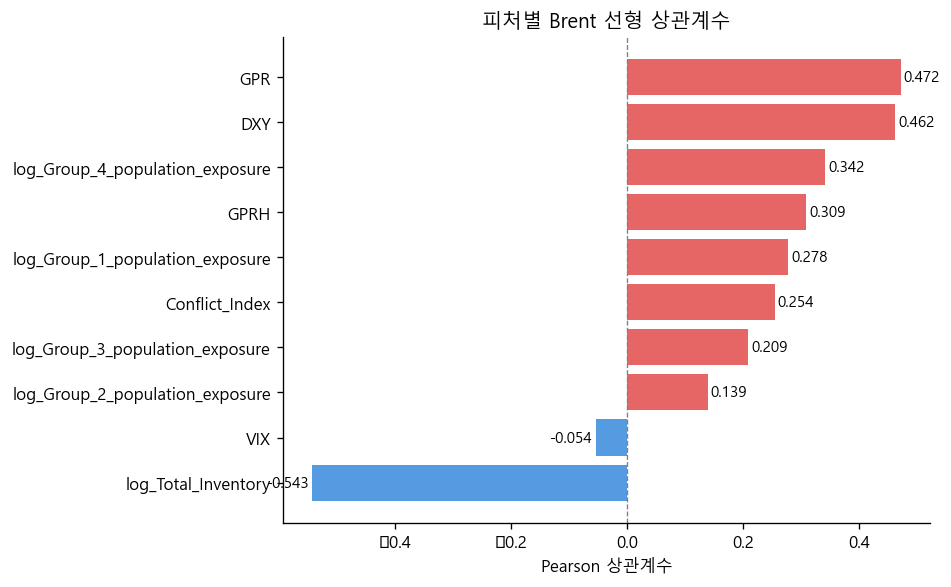

In [136]:
corr = df_model[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E24B4A' if v > 0 else '#378ADD' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Pearson 상관계수')
ax.set_title(f'피처별 {TARGET} 선형 상관계수')
for i, (feat, val) in enumerate(corr.items()):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

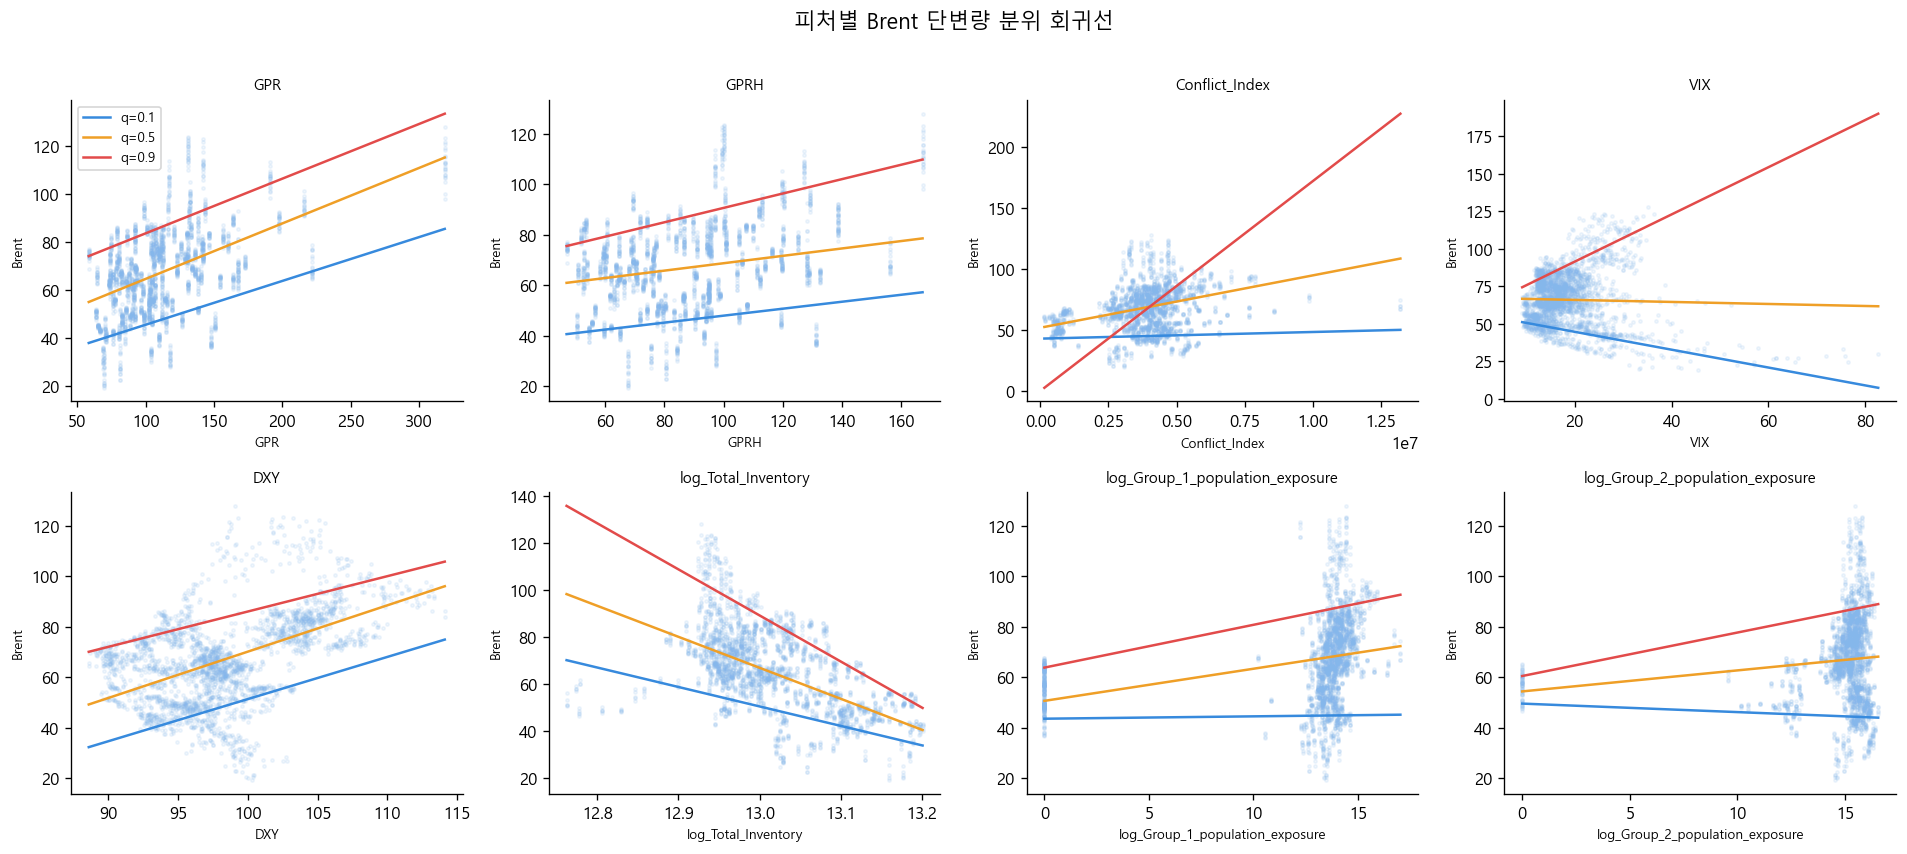

In [137]:
# 핵심 피처 산점도 — 단변량 분위 회귀선 포함
KEY_FEATS = ['GPR', 'GPRH', 'Conflict_Index', 'VIX',
             'DXY', 'log_Total_Inventory',
             'log_Group_1_population_exposure',
             'log_Group_2_population_exposure']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_FEATS):
    x = df_model[feat].values
    y = df_model[TARGET].values
    ax.scatter(x, y, alpha=0.12, s=4, color='#85B7EB')

    X_s    = sm.add_constant(x)
    x_line = np.linspace(x.min(), x.max(), 100)
    X_line = sm.add_constant(x_line)
    for q in QUANTILES:
        res = QuantReg(y, X_s).fit(q=q, max_iter=1000)
        ax.plot(x_line, res.predict(X_line),
                color=Q_COLORS[q], linewidth=1.5,
                label=f'q={q}' if feat == KEY_FEATS[0] else '')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    ax.set_title(feat, fontsize=9)

axes[0].legend(fontsize=8)
plt.suptitle(f'피처별 {TARGET} 단변량 분위 회귀선', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 4. Train / Test Split

시계열 특성상 **시간 기준으로 분할** (최근 20% → Test)

Train: 2,242건  (2014-12-22 ~ 2023-12-11)
Test : 561건   (2023-12-12 ~ 2026-03-06)


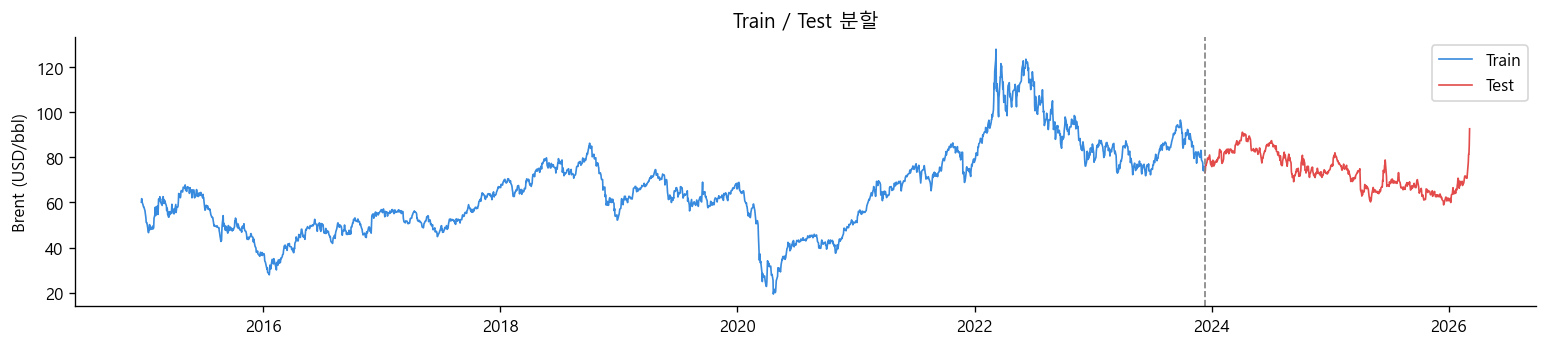

In [138]:
split_idx = int(len(df_model) * 0.8)
df_train = df_model.iloc[:split_idx].copy()
df_test  = df_model.iloc[split_idx:].copy()

X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test[TARGET].values

print(f'Train: {len(df_train):,}건  ({df_train["Date"].min().date()} ~ {df_train["Date"].max().date()})')
print(f'Test : {len(df_test):,}건   ({df_test["Date"].min().date()} ~ {df_test["Date"].max().date()})')

# 시각화로 분할 구간 확인
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df_train['Date'], df_train[TARGET], color='#378ADD', linewidth=1, label='Train')
ax.plot(df_test['Date'],  df_test[TARGET],  color='#E24B4A', linewidth=1, label='Test')
ax.axvline(df_test['Date'].iloc[0], color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Brent (USD/bbl)')
ax.set_title('Train / Test 분할')
ax.legend()
plt.tight_layout()
plt.show()

# 5. V1 — 기본 모델 (원본 10개 피처)

원본 10개 피처 전체를 사용한 베이스라인 모델.  
이 단계에서 다중공선성·분위 교차·밴드 붕괴 등 3가지 문제를 확인하고 이후 버전 개선의 근거를 마련한다.

## 5-1. 선형 분위 회귀 (QuantReg)

**statsmodels QuantReg** 사용.  
각 분위(q=0.1/0.5/0.9)에 대해 독립적으로 회귀 계수를 추정한다.


In [139]:
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

qr_results = {}
for q in QUANTILES:
    res = QuantReg(y_train, X_train_sm).fit(q=q, max_iter=3000)
    qr_results[q] = res

    pred    = res.predict(X_test_sm)
    mae     = mean_absolute_error(y_test, pred)
    e       = y_test - pred
    pinball = np.mean(np.where(e >= 0, q * e, (q - 1) * e))
    print(f'q={q:.1f} | Pseudo R²={res.prsquared:.4f} | MAE={mae:.2f} | Pinball={pinball:.4f}')

q=0.1 | Pseudo R²=0.3038 | MAE=20.00 | Pinball=1.9997
q=0.5 | Pseudo R²=0.2996 | MAE=5.90 | Pinball=2.9505
q=0.9 | Pseudo R²=0.4091 | MAE=16.64 | Pinball=1.6686


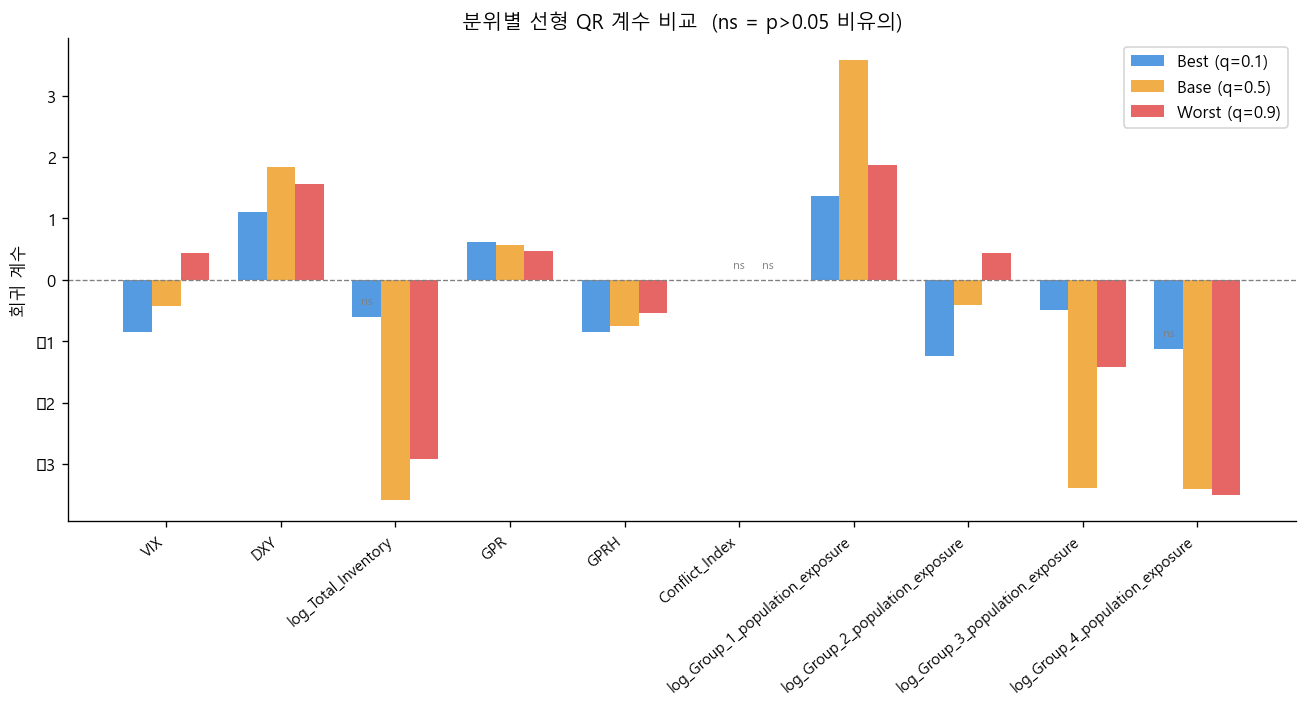


=== 계수 상세 ===
                                   q0.1    q0.5    q0.9
VIX                             -0.8440 -0.4279  0.4277
DXY                              1.1073  1.8310  1.5667
log_Total_Inventory             -0.5987 -3.5799 -2.9259
GPR                              0.6148  0.5591  0.4644
GPRH                            -0.8511 -0.7572 -0.5482
Conflict_Index                  -0.0000 -0.0000 -0.0000
log_Group_1_population_exposure  1.3630  3.5734  1.8704
log_Group_2_population_exposure -1.2350 -0.4123  0.4314
log_Group_3_population_exposure -0.4896 -3.3845 -1.4134
log_Group_4_population_exposure -1.1205 -3.4054 -3.4986


In [140]:
# ── 분위별 계수 비교 ──────────────────────────────────────
feat_names = ['const'] + FEATURE_COLS

coef_df = pd.DataFrame(
    {f'q{q}': qr_results[q].params for q in QUANTILES},
    index=feat_names
).loc[FEATURE_COLS]

pval_df = pd.DataFrame(
    {f'q{q}': qr_results[q].pvalues for q in QUANTILES},
    index=feat_names
).loc[FEATURE_COLS]

fig, ax = plt.subplots(figsize=(11, 6))
x     = np.arange(len(FEATURE_COLS))
width = 0.25

for i, q in enumerate(QUANTILES):
    bars = ax.bar(x + (i - 1) * width, coef_df[f'q{q}'],
                  width, color=Q_COLORS[q], alpha=0.85, label=Q_LABELS[q])
    for bar, pval in zip(bars, pval_df[f'q{q}']):
        if pval > 0.05:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.15, 'ns',
                    ha='center', va='bottom', fontsize=7, color='gray')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLS, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('회귀 계수')
ax.set_title('분위별 선형 QR 계수 비교  (ns = p>0.05 비유의)')
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== 계수 상세 ===')
print(coef_df.round(4).to_string())

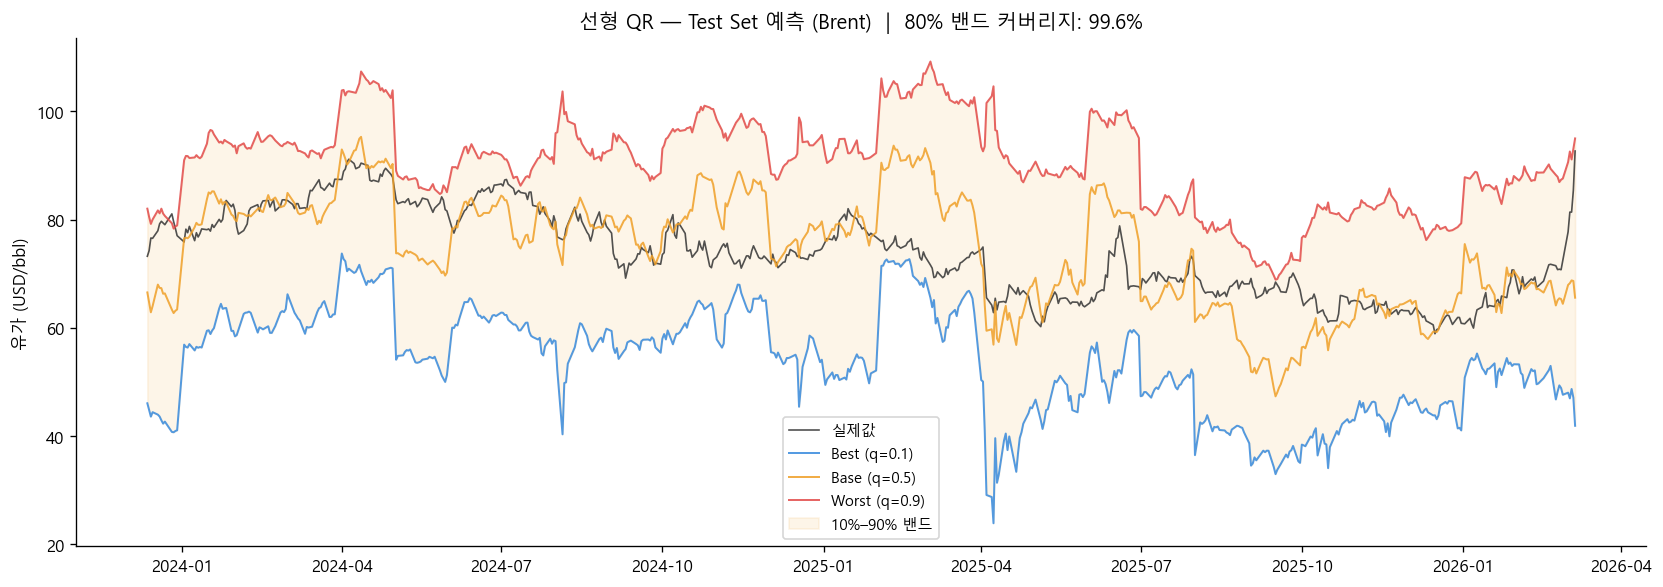

In [141]:
# ── Test Set 예측 + 밴드 시각화 ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_test['Date'], y_test,
        color='#333', linewidth=1, label='실제값', alpha=0.85)

for q in QUANTILES:
    pred = qr_results[q].predict(X_test_sm)
    ax.plot(df_test['Date'], pred,
            color=Q_COLORS[q], linewidth=1.2,
            label=Q_LABELS[q], alpha=0.85)

pred_low  = qr_results[0.1].predict(X_test_sm)
pred_high = qr_results[0.9].predict(X_test_sm)
ax.fill_between(df_test['Date'], pred_low, pred_high,
                alpha=0.10, color='#EF9F27', label='10%–90% 밴드')

coverage = np.mean((y_test >= pred_low) & (y_test <= pred_high))
ax.set_title(f'선형 QR — Test Set 예측 ({TARGET})  |  80% 밴드 커버리지: {coverage:.1%}')
ax.set_ylabel('유가 (USD/bbl)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5-2. LightGBM Quantile

`objective='quantile'`, `alpha=q` 설정으로 각 분위수를 직접 학습.  
비선형 임계 효과(예: 분쟁 지수 급등 시 유가 반응)를 포착한다.


In [142]:
lgbm_models    = {}
lgbm_preds_test = {}

LGBM_PARAMS = dict(
    n_estimators     = 500,
    learning_rate    = 0.03,
    num_leaves       = 63,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.05,
    reg_lambda       = 0.1,
    random_state     = 42,
    verbose          = -1,
)

for q in QUANTILES:
    model = LGBMRegressor(objective='quantile', alpha=q, **LGBM_PARAMS)
    model.fit(X_train, y_train)
    lgbm_models[q]      = model
    pred = model.predict(X_test)
    lgbm_preds_test[q]  = pred

    mae     = mean_absolute_error(y_test, pred)
    e       = y_test - pred
    pinball = np.mean(np.where(e >= 0, q * e, (q - 1) * e))
    print(f'q={q:.1f} | MAE={mae:.2f} | Pinball={pinball:.4f}')

q=0.1 | MAE=7.65 | Pinball=4.2394
q=0.5 | MAE=9.95 | Pinball=4.9762
q=0.9 | MAE=10.33 | Pinball=1.8666


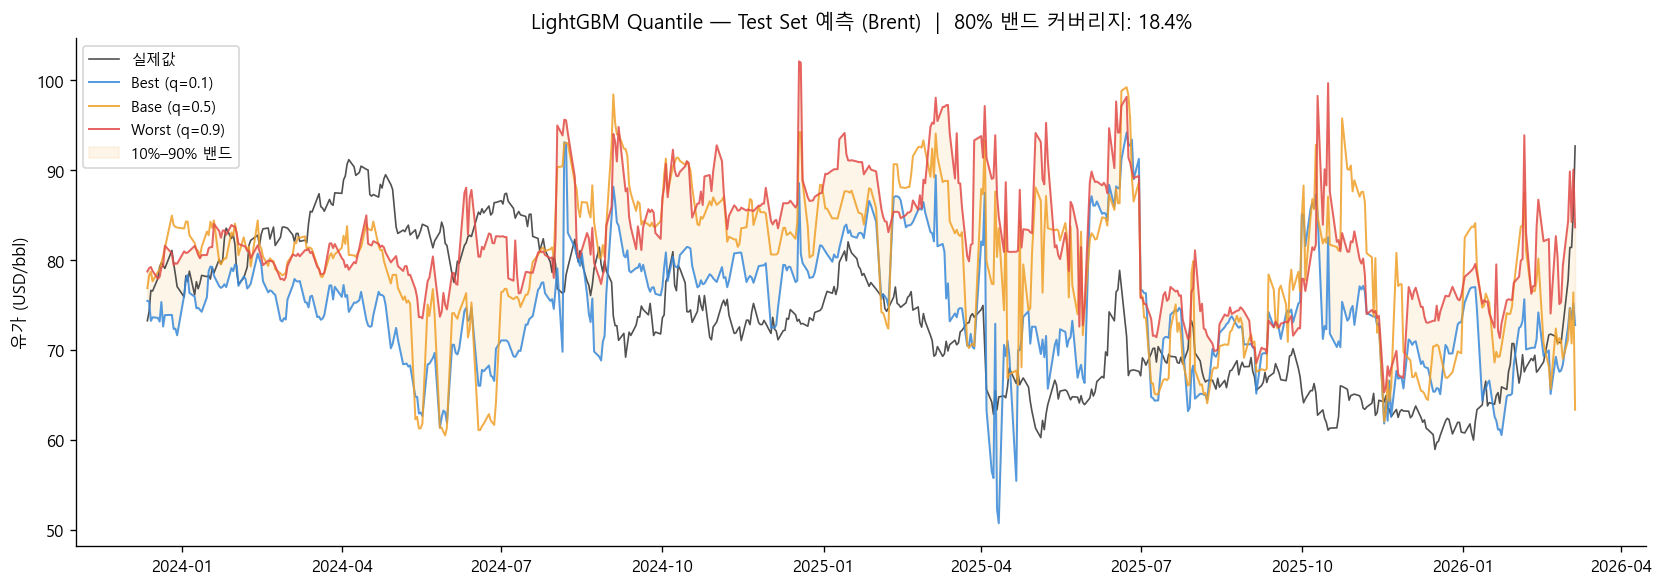

In [143]:
# ── Test Set 예측 + 밴드 시각화 ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_test['Date'], y_test,
        color='#333', linewidth=1, label='실제값', alpha=0.85)

for q in QUANTILES:
    ax.plot(df_test['Date'], lgbm_preds_test[q],
            color=Q_COLORS[q], linewidth=1.2,
            label=Q_LABELS[q], alpha=0.85)

ax.fill_between(df_test['Date'],
                lgbm_preds_test[0.1], lgbm_preds_test[0.9],
                alpha=0.10, color='#EF9F27', label='10%–90% 밴드')

coverage = np.mean(
    (y_test >= lgbm_preds_test[0.1]) & (y_test <= lgbm_preds_test[0.9])
)
ax.set_title(f'LightGBM Quantile — Test Set 예측 ({TARGET})  |  80% 밴드 커버리지: {coverage:.1%}')
ax.set_ylabel('유가 (USD/bbl)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

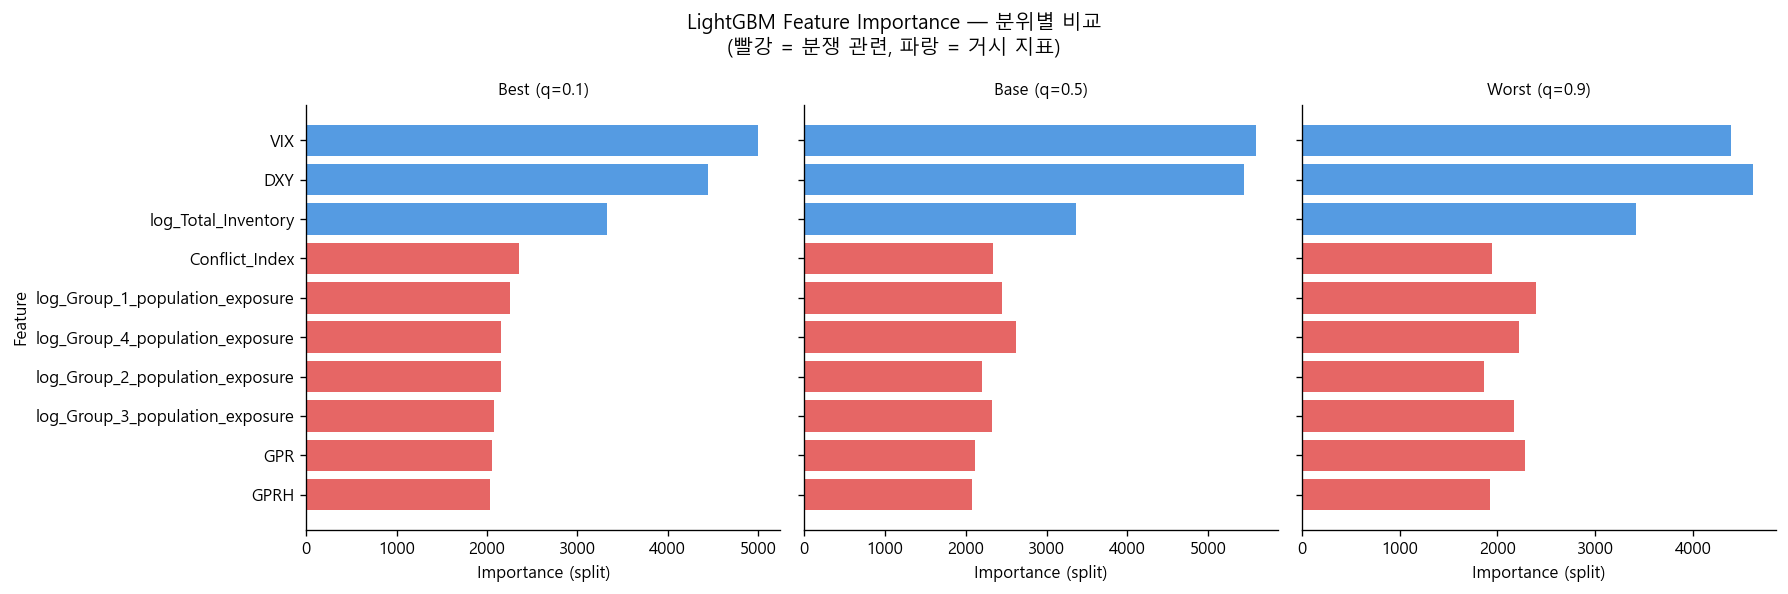

In [144]:
# ── 분위별 Feature Importance 비교 ───────────────────────
CONFLICT_FEATS = {
    'GPR', 'GPRH', 'Conflict_Index',
    'log_Group_1_population_exposure',
    'log_Group_2_population_exposure',
    'log_Group_3_population_exposure',
    'log_Group_4_population_exposure',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, q in zip(axes, QUANTILES):
    imp = pd.Series(
        lgbm_models[q].feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=True)

    bar_colors = ['#E24B4A' if f in CONFLICT_FEATS else '#378ADD'
                  for f in imp.index]
    ax.barh(imp.index, imp.values, color=bar_colors, alpha=0.85)
    ax.set_title(Q_LABELS[q], fontsize=10)
    ax.set_xlabel('Importance (split)')

axes[0].set_ylabel('Feature')
fig.suptitle(
    'LightGBM Feature Importance — 분위별 비교\n'
    '(빨강 = 분쟁 관련, 파랑 = 거시 지표)',
    fontsize=12
)
plt.tight_layout()
plt.show()

---

# 6. V1 → V2: 문제 진단

V1 모델에서 발견된 3가지 구조적 결함을 진단하고, V2에서의 수정 방향을 제시한다.

| # | 문제 | 원인 | 영향 |
|---|------|------|------|
| 1 | `Conflict_Index` 다중공선성 | `Group_1~4`의 가중합 → 원 피처와 선형 관계 | QuantReg 계수 불안정, VIF 폭등 |
| 2 | LightGBM 분위 교차 | 각 분위 독립 학습 → q=0.1 > q=0.9 역전 가능 | 밴드 해석 불가 |
| 3 | 시나리오 밴드 붕괴 | LGBM 밴드가 QR 대비 과도하게 좁음 | Worst 시나리오 과소평가 |


=== VIF (10 초과 → 다중공선성 위험) ===
                        Feature         VIF
log_Group_4_population_exposure 2899.215102
            log_Total_Inventory 2528.823430
                            DXY  688.360876
                           GPRH   97.135127
log_Group_2_population_exposure   86.106250
log_Group_1_population_exposure   77.231114
                            GPR   61.394018
log_Group_3_population_exposure   34.955738
                 Conflict_Index   20.231355
                            VIX    9.251757


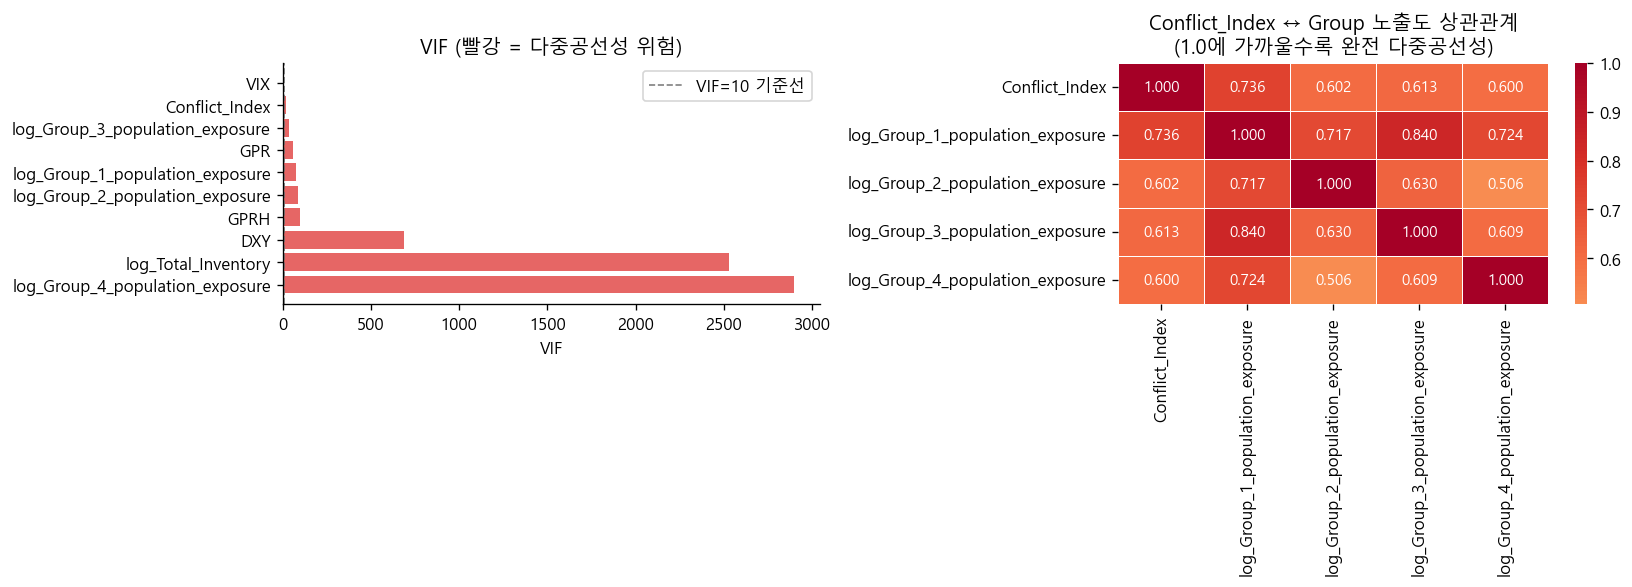

In [145]:
# ── 문제 1: Conflict_Index 다중공선성 ────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif   = df_model[FEATURE_COLS].values
vif_df  = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'VIF': [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('=== VIF (10 초과 → 다중공선성 위험) ===')
print(vif_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VIF 막대그래프
bar_colors = ['#E24B4A' if v > 10 else '#378ADD' for v in vif_df['VIF']]
axes[0].barh(vif_df['Feature'], vif_df['VIF'], color=bar_colors, alpha=0.85)
axes[0].axvline(10, color='gray', linestyle='--', linewidth=1, label='VIF=10 기준선')
axes[0].set_title('VIF (빨강 = 다중공선성 위험)')
axes[0].set_xlabel('VIF')
axes[0].legend()

# 상관관계 히트맵 (Conflict_Index vs Group 노출도)
conflict_cols = ['Conflict_Index'] + [f'log_Group_{i}_population_exposure' for i in range(1, 5)]
corr_mat = df_model[conflict_cols].corr()
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 9})
axes[1].set_title('Conflict_Index ↔ Group 노출도 상관관계\n(1.0에 가까울수록 완전 다중공선성)')

plt.tight_layout()
plt.show()

분위 교차 발생: 305건 / 561건 (54.4%)


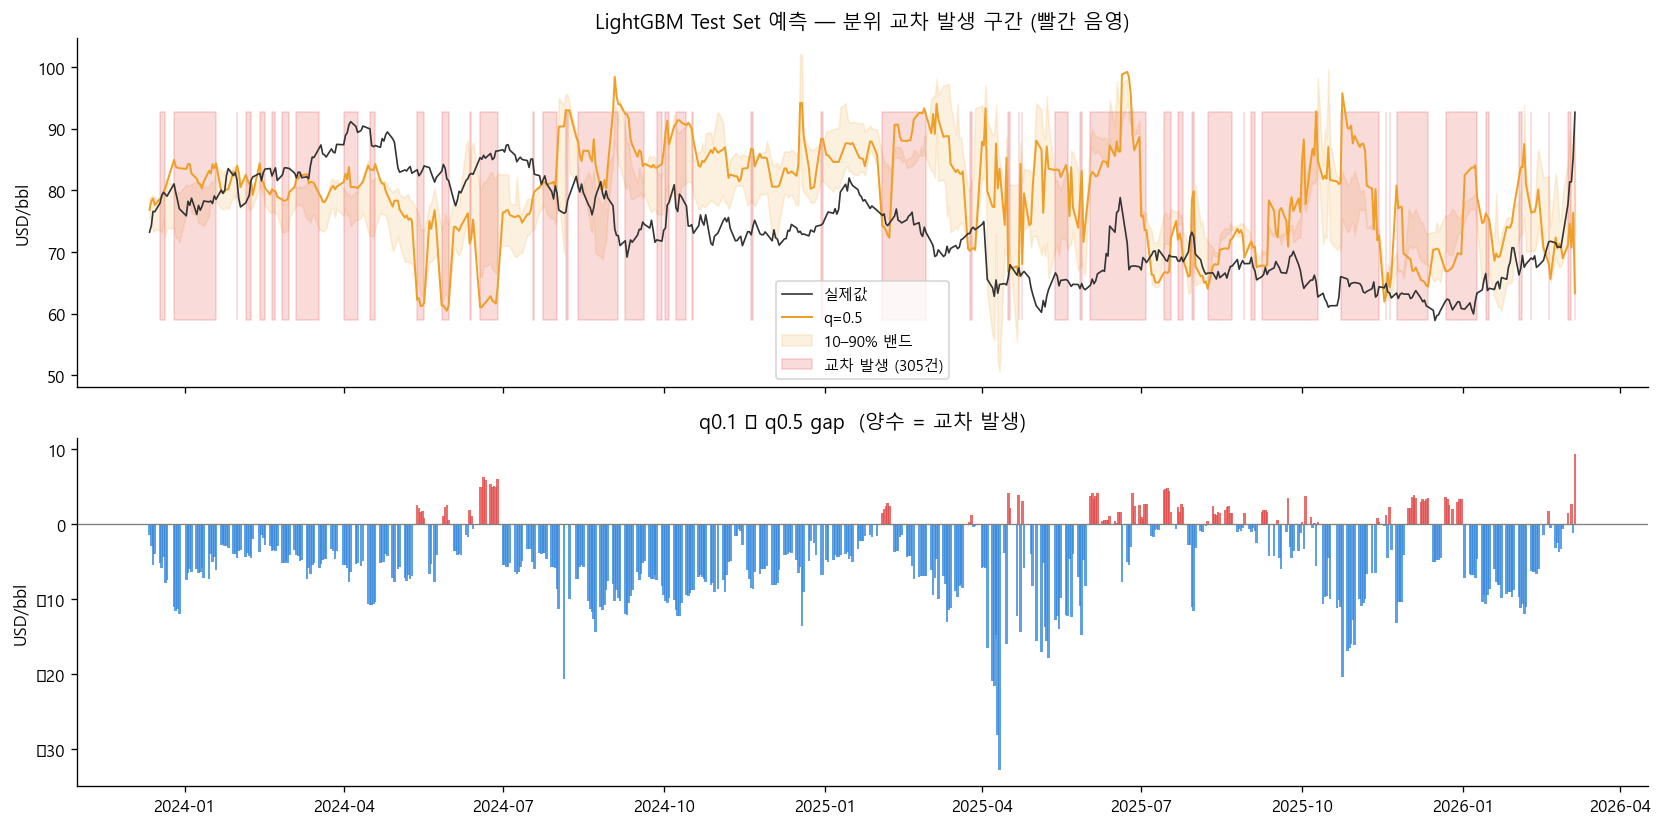

In [146]:
# ── 문제 2: LightGBM 분위 교차 시각화 ────────────────────
low  = lgbm_preds_test[0.1]
mid  = lgbm_preds_test[0.5]
high = lgbm_preds_test[0.9]

cross_mask = (low > mid) | (mid > high)
print(f'분위 교차 발생: {cross_mask.sum()}건 / {len(cross_mask)}건 ({cross_mask.mean():.1%})')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# 위: 실제값 + 예측 밴드 (교차 구간 강조)
axes[0].plot(df_test['Date'], y_test, color='#333', linewidth=1, label='실제값', zorder=5)
axes[0].plot(df_test['Date'], mid,  color='#EF9F27', linewidth=1.2, label='q=0.5')
axes[0].fill_between(df_test['Date'], low, high,
                     alpha=0.15, color='#EF9F27', label='10–90% 밴드')
# 교차 구간 빨간 음영
axes[0].fill_between(df_test['Date'], y_test.min(), y_test.max(),
                     where=cross_mask, alpha=0.20, color='#E24B4A',
                     label=f'교차 발생 ({cross_mask.sum()}건)')
axes[0].set_title('LightGBM Test Set 예측 — 분위 교차 발생 구간 (빨간 음영)')
axes[0].set_ylabel('USD/bbl')
axes[0].legend(fontsize=9)

# 아래: q0.1 - q0.5 gap (음수면 교차)
gap = low - mid
axes[1].bar(df_test['Date'], gap,
            color=np.where(gap > 0, '#E24B4A', '#378ADD'),
            width=1.5, alpha=0.8)
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('q0.1 − q0.5 gap  (양수 = 교차 발생)')
axes[1].set_ylabel('USD/bbl')

plt.tight_layout()
plt.show()

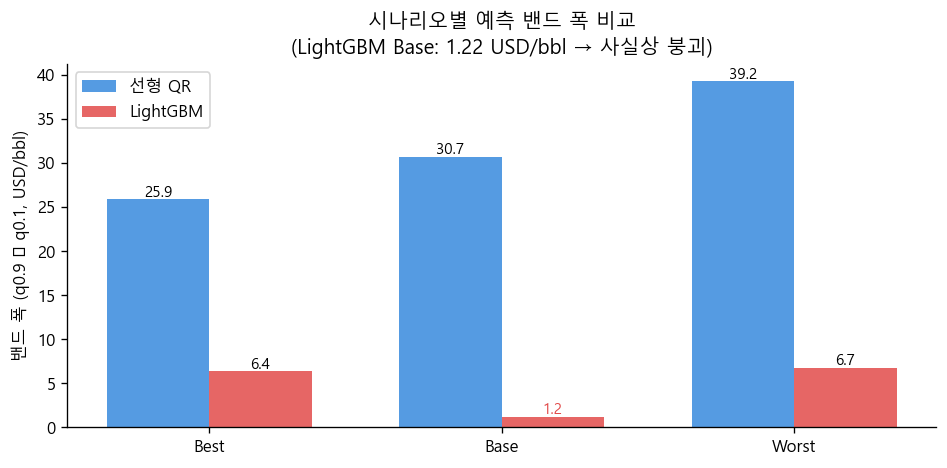

In [147]:
# ── 문제 3: LightGBM 시나리오 밴드 붕괴 ─────────────────
qr_band   = {'Best': 75.18-49.32, 'Base': 81.49-50.83, 'Worst': 74.91-35.67}
lgbm_band = {'Best':  61.97-55.62, 'Base': 66.00-64.78, 'Worst': 66.20-59.47}

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.35
scen_names = ['Best', 'Base', 'Worst']

ax.bar(x - w/2, [qr_band[s]   for s in scen_names], w,
       color='#378ADD', alpha=0.85, label='선형 QR')
ax.bar(x + w/2, [lgbm_band[s] for s in scen_names], w,
       color='#E24B4A', alpha=0.85, label='LightGBM')

for i, s in enumerate(scen_names):
    ax.text(i - w/2, qr_band[s]   + 0.3, f'{qr_band[s]:.1f}',   ha='center', fontsize=9)
    ax.text(i + w/2, lgbm_band[s] + 0.3, f'{lgbm_band[s]:.1f}', ha='center', fontsize=9,
            color='#E24B4A' if lgbm_band[s] < 5 else 'black')

ax.set_xticks(x)
ax.set_xticklabels(scen_names)
ax.set_ylabel('밴드 폭 (q0.9 − q0.1, USD/bbl)')
ax.set_title('시나리오별 예측 밴드 폭 비교\n(LightGBM Base: 1.22 USD/bbl → 사실상 붕괴)')
ax.legend()
plt.tight_layout()
plt.show()

---

# 7. V2 — Conflict_Index 제거 (9개 피처)

V1 문제 진단 결과를 반영한 첫 번째 개선 버전.

| Step | 내용 | 목적 |
|------|------|------|
| 1 | `Conflict_Index` 피처 제거 | 다중공선성 해소 (`Group_1~4`와 선형 중복) |
| 2 | Isotonic Sort 적용 | LightGBM 분위 교차(역전) 강제 제거 |
| 3 | 전체 재학습 | V2 피처셋(`FEATURE_COLS_V2`, 9개)으로 QR + LGBM 재학습 |


In [148]:
# Step 1. Conflict_Index 제거 → FEATURE_COLS_V2
FEATURE_COLS_V2 = [f for f in FEATURE_COLS if f != 'Conflict_Index']
print(f'제거: Conflict_Index')
print(f'기존 피처 수: {len(FEATURE_COLS)}  →  수정 후: {len(FEATURE_COLS_V2)}')
print(f'FEATURE_COLS_V2: {FEATURE_COLS_V2}')

X_train_v2    = df_train[FEATURE_COLS_V2].values
X_test_v2     = df_test[FEATURE_COLS_V2].values
X_train_sm_v2 = sm.add_constant(X_train_v2)
X_test_sm_v2  = sm.add_constant(X_test_v2)

제거: Conflict_Index
기존 피처 수: 10  →  수정 후: 9
FEATURE_COLS_V2: ['VIX', 'DXY', 'log_Total_Inventory', 'GPR', 'GPRH', 'log_Group_1_population_exposure', 'log_Group_2_population_exposure', 'log_Group_3_population_exposure', 'log_Group_4_population_exposure']


In [149]:
# Step 2. 수정된 피처셋으로 재학습
qr_v2   = {}
lgbm_v2 = {}
lgbm_preds_v2 = {}

for q in QUANTILES:
    # QR
    res = QuantReg(y_train, X_train_sm_v2).fit(q=q, max_iter=3000)
    qr_v2[q] = res

    # LightGBM
    model = LGBMRegressor(objective='quantile', alpha=q, **LGBM_PARAMS)
    model.fit(X_train_v2, y_train)
    lgbm_v2[q]        = model
    lgbm_preds_v2[q]  = model.predict(X_test_v2)

print('재학습 완료')

# Step 3. LightGBM Isotonic Sort (분위 교차 보정)
def isotonic_sort(preds):
    """각 샘플의 세 분위 예측을 오름차순 정렬 → 교차 원천 차단"""
    stacked = np.sort(
        np.column_stack([preds[0.1], preds[0.5], preds[0.9]]),
        axis=1
    )
    return {0.1: stacked[:, 0], 0.5: stacked[:, 1], 0.9: stacked[:, 2]}

lgbm_sorted_v2 = isotonic_sort(lgbm_preds_v2)

cross_before = np.mean((lgbm_preds_v2[0.1] > lgbm_preds_v2[0.5]) |
                       (lgbm_preds_v2[0.5] > lgbm_preds_v2[0.9]))
cross_after  = np.mean((lgbm_sorted_v2[0.1] > lgbm_sorted_v2[0.5]) |
                       (lgbm_sorted_v2[0.5] > lgbm_sorted_v2[0.9]))

print(f'분위 교차  보정 전: {cross_before:.1%}')
print(f'분위 교차  보정 후: {cross_after:.1%}  ✅')

재학습 완료
분위 교차  보정 전: 49.0%
분위 교차  보정 후: 0.0%  ✅


=== Before / After 비교 ===

                  coverage      mae  pb_low  pb_mid  pb_high  winkler  crossing
name                                                                           
선형 QR (원본)          0.9964   5.9009  1.9997  2.9505   1.6686  36.6831    0.0000
선형 QR (v2)          0.8556  10.2668  1.2337  5.1334   1.9715  32.0519    0.0000
LightGBM (원본)       0.1836   9.9525  4.2394  4.9762   1.8666  61.0593    0.5437
LightGBM (v2+정렬)    0.2406   8.9933  3.5335  4.4966   1.7741  53.0765    0.0000


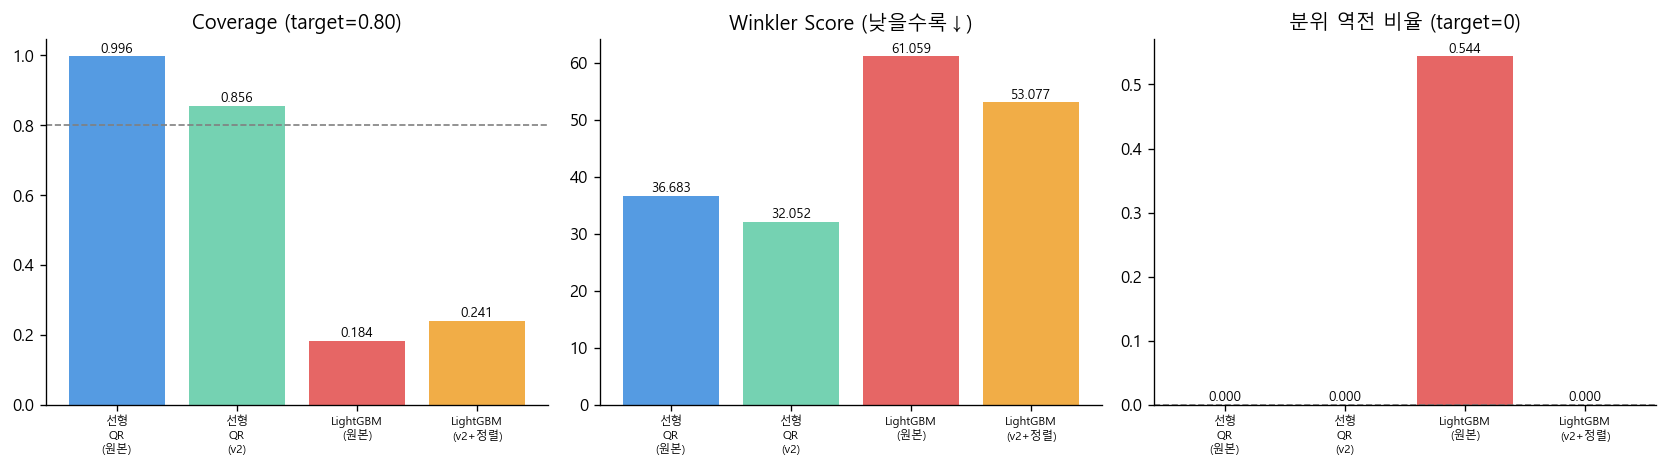

In [150]:
# ── 평가 함수 (전 버전 공통) ───────────────────────────────────────────────
def eval_summary(name, preds, y_true):
    low, mid, high = preds[0.1], preds[0.5], preds[0.9]
    coverage  = float(np.mean((y_true >= low) & (y_true <= high)))
    mae       = float(mean_absolute_error(y_true, mid))
    # pinball: q=0.1 / 0.5 / 0.9 각각 계산
    def pinball(q, pred): e = y_true - pred; return float(np.mean(np.where(e>=0, q*e, (q-1)*e)))
    pb_low  = pinball(0.1, low)
    pb_mid  = pinball(0.5, mid)
    pb_high = pinball(0.9, high)
    # Winkler score (alpha=0.2, 즉 80% 구간)
    alpha   = 0.2
    bw      = high - low
    penalty = (np.where(y_true < low,  (2/alpha)*(low  - y_true), 0) +
               np.where(y_true > high, (2/alpha)*(y_true - high), 0))
    winkler  = float(np.mean(bw + penalty))
    crossing = float(np.mean((low > mid) | (mid > high)))
    return dict(name=name,
                coverage=coverage, mae=mae,
                pb_low=pb_low, pb_mid=pb_mid, pb_high=pb_high,
                winkler=winkler, crossing=crossing)

# ── Before / After 비교 (V1 vs V2) ─────────────────────────────────────────
rows = [
    eval_summary('선형 QR (원본)',         {q: qr_results[q].predict(X_test_sm) for q in QUANTILES},  y_test),
    eval_summary('선형 QR (v2)',           qr_preds_v2,    y_test),
    eval_summary('LightGBM (원본)',        lgbm_preds_test, y_test),
    eval_summary('LightGBM (v2+정렬)',     lgbm_sorted_v2,  y_test),
]

cmp_df = pd.DataFrame(rows).set_index('name')
print('=== Before / After 비교 ===\n')
print(cmp_df[['coverage','mae','pb_low','pb_mid','pb_high','winkler','crossing']].round(4).to_string())

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [('coverage', 'Coverage (target=0.80)', 0.80),
           ('winkler',  'Winkler Score (낮을수록↓)',  None),
           ('crossing', '분위 역전 비율 (target=0)', 0.0)]

colors = ['#378ADD', '#5DCAA5', '#E24B4A', '#EF9F27']
for ax, (col, title, target) in zip(axes, metrics):
    vals = cmp_df[col].values
    bars = ax.bar(range(4), vals, color=colors, alpha=0.85)
    if target is not None:
        ax.axhline(target, color='gray', linestyle='--', linewidth=1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(abs(vals))*0.01,
                f'{v:.3f}', ha='center', fontsize=8)
    ax.set_xticks(range(4))
    ax.set_xticklabels([r.replace(' ', '\n') for r in cmp_df.index], fontsize=7)
    ax.set_title(title)

plt.tight_layout()
plt.show()


---

# 8. V3 — VIF 기반 피처 축소 (5개 피처)

V2에서도 `log_Group_4`(VIF=2,899), `log_Total_Inventory`(VIF=2,529), `DXY`(VIF=688), `GPRH`(VIF=97) 등 여전히 높은 VIF가 잔존.  
선형 계수 해석의 안정화를 목적으로 대표 피처만 남기고 제거.

**V3 축소 기준 (대표 피처 유지 원칙):**
- `log_Group_1~4` 중 → **Group_1만 유지** (이란·호르무즈 핵심 경로, 다른 그룹과 중복)
- `GPR`과 `GPRH` 중 → **GPR만 유지** (Headline 대비 포괄 지표)
- `log_Total_Inventory`, `DXY`, `VIX`는 유지 (의미 있는 독립 채널)

→ `FEATURE_COLS_V3 = ['VIX', 'DXY', 'log_Total_Inventory', 'GPR', 'log_Group_1_population_exposure']`

> ⚠️ **한계**: VIF 제거는 계수 해석에 유리하지만,  
> **예측 + 밴드**가 목표인 경우 정보를 버리는 셈. → V4에서 재검토.


In [151]:
# ── Step 4: FEATURE_COLS_V3 정의 및 VIF 재확인 ────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

FEATURE_COLS_V3 = [
    'VIX', 'DXY', 'log_Total_Inventory', 'GPR',
    'log_Group_1_population_exposure'
]

X_v3_all = df_model[FEATURE_COLS_V3].dropna()
vif_v3 = pd.DataFrame({
    'Feature': FEATURE_COLS_V3,
    'VIF': [variance_inflation_factor(X_v3_all.values, i)
            for i in range(len(FEATURE_COLS_V3))]
}).sort_values('VIF', ascending=False)
print("=== V3 VIF ===")
print(vif_v3.to_string(index=False))

# ── Step 5: V3 모델 학습 ──────────────────────────────────────────────────────
# df_train / df_test는 cell 10에서 정의됨 (numpy array 대신 DataFrame으로 슬라이싱)
X_train_v3    = df_train[FEATURE_COLS_V3].values
X_test_v3     = df_test[FEATURE_COLS_V3].values
X_train_sm_v3 = sm.add_constant(X_train_v3)
X_test_sm_v3  = sm.add_constant(X_test_v3)

QUANTILES = [0.1, 0.5, 0.9]

# 선형 QR v3
qr_v3 = {}
for q in QUANTILES:
    res = QuantReg(y_train, X_train_sm_v3).fit(q=q, max_iter=3000)
    qr_v3[q] = res
print("선형 QR v3 학습 완료")

# LightGBM v3
lgbm_v3       = {}
lgbm_preds_v3 = {}
for q in QUANTILES:
    m = LGBMRegressor(objective='quantile', alpha=q, **LGBM_PARAMS)
    m.fit(X_train_v3, y_train)
    lgbm_v3[q]       = m
    lgbm_preds_v3[q] = m.predict(X_test_v3)
print("LightGBM v3 학습 완료")

# Isotonic Sort
lgbm_sorted_v3 = isotonic_sort(lgbm_preds_v3)

# QR v3 예측
qr_preds_v3 = {q: qr_v3[q].predict(X_test_sm_v3) for q in QUANTILES}

=== V3 VIF ===
                        Feature        VIF
                            DXY 495.684754
            log_Total_Inventory 431.238619
                            GPR  12.906672
log_Group_1_population_exposure  11.486104
                            VIX   7.836266
선형 QR v3 학습 완료
LightGBM v3 학습 완료


=== V2 vs V3 비교 (Test set) ===

               coverage      mae  pb_low  pb_mid  pb_high  winkler  crossing
name                                                                        
선형 QR (v2)       0.8556  10.2668  1.2337  5.1334   1.9715  32.0519       0.0
선형 QR (v3)       0.7326  12.8514  1.3330  6.4257   2.2473  35.8028       0.0
LightGBM (v2)    0.2406   8.9933  3.5335  4.4966   1.7741  53.0765       0.0
LightGBM (v3)    0.2121  10.6595  5.3438  5.3298   1.8792  72.2301       0.0


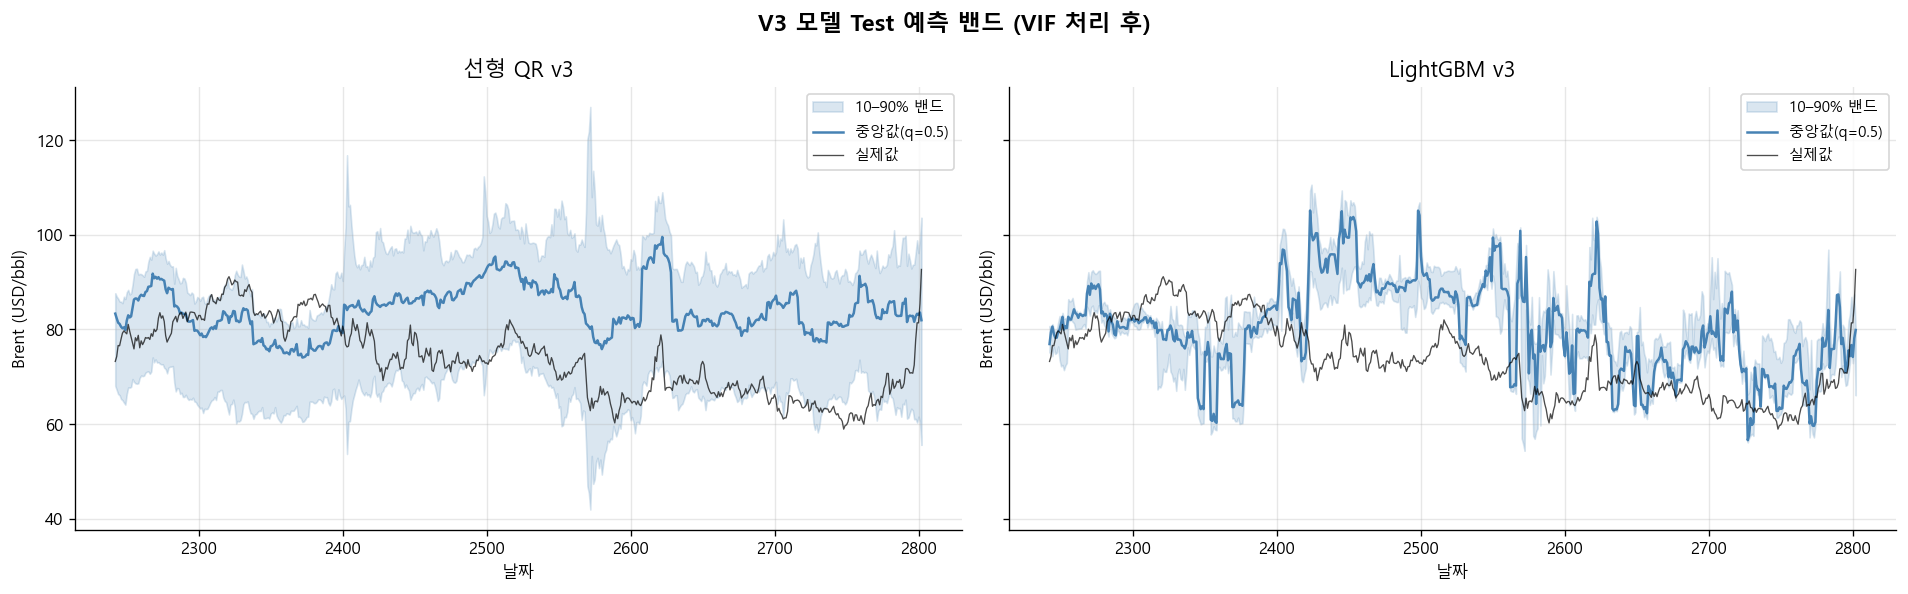

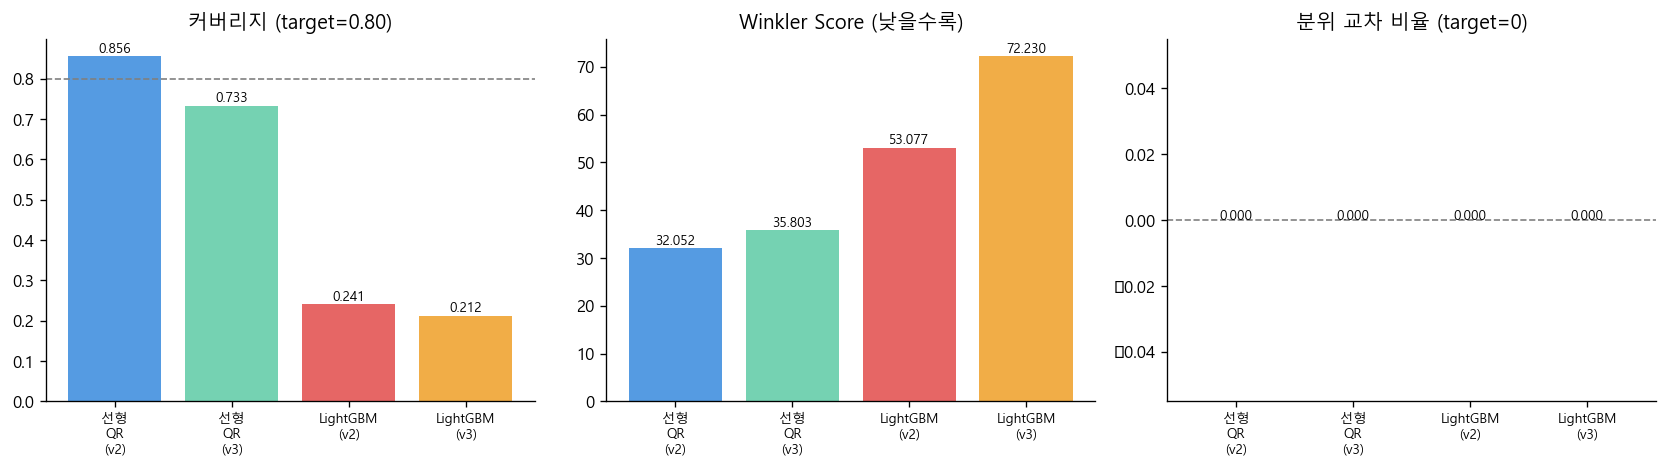

In [152]:
# ── V2 vs V3 성능 비교 ────────────────────────────────────────────────────────
rows = [
    eval_summary('선형 QR (v2)',       qr_preds_v2,    y_test),
    eval_summary('선형 QR (v3)',       qr_preds_v3,    y_test),
    eval_summary('LightGBM (v2)',      lgbm_sorted_v2, y_test),
    eval_summary('LightGBM (v3)',      lgbm_sorted_v3, y_test),
]
cmp_v3 = pd.DataFrame(rows).set_index('name')
print("=== V2 vs V3 비교 (Test set) ===\n")
print(cmp_v3[['coverage','mae','pb_low','pb_mid','pb_high','winkler','crossing']].round(4).to_string())

# ── 시각화: V3 예측 밴드 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
titles      = ['선형 QR v3', 'LightGBM v3']
preds_list  = [qr_preds_v3, lgbm_sorted_v3]

for ax, title, preds in zip(axes, titles, preds_list):
    ax.fill_between(df_test.index, preds[0.1], preds[0.9],
                    alpha=0.2, color='steelblue', label='10–90% 밴드')
    ax.plot(df_test.index, preds[0.5], color='steelblue', lw=1.5, label='중앙값(q=0.5)')
    ax.plot(df_test.index, y_test,     color='black', lw=0.8, alpha=0.7, label='실제값')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('날짜')
    ax.set_ylabel('Brent (USD/bbl)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('V3 모델 Test 예측 밴드 (VIF 처리 후)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── V2 vs V3 지표 막대 비교 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [('coverage', '커버리지 (target=0.80)', 0.80),
           ('winkler',  'Winkler Score (낮을수록)',  None),
           ('crossing', '분위 교차 비율 (target=0)', 0.0)]
colors = ['#378ADD', '#5DCAA5', '#E24B4A', '#EF9F27']

for ax, (col, title, target) in zip(axes, metrics):
    vals = cmp_v3[col].values
    bars = ax.bar(range(4), vals, color=colors, alpha=0.85)
    if target is not None:
        ax.axhline(target, color='gray', linestyle='--', linewidth=1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.3f}', ha='center', fontsize=8)
    ax.set_xticks(range(4))
    ax.set_xticklabels([r.replace(' ', '\n') for r in cmp_v3.index], fontsize=8)
    ax.set_title(title)

plt.tight_layout()
plt.show()

---

# 9. V4 — 피처 복원 + Lag 효과 (13개 피처)

## V3의 한계 재검토

VIF 기반 피처 제거는 **계수 해석이 목적일 때** 유효하다.  
**예측 + 밴드**가 목표인 현재 상황에서는:

| 모델 | 다중공선성 영향 |
|------|----------------|
| LightGBM (트리 기반) | **거의 없음** — 상관 피처를 알아서 처리, 제거 시 오히려 정보 손실 |
| QuantReg | SE(표준오차)를 부풀리지만 **예측값 자체에는 큰 영향 없음** |

## V4 전략

1. **피처 복원**: VIF 기준으로 제거했던 원래 10개 피처 전체 복원
2. **Lag 피처 추가**: 유가는 자기상관이 강함 → `Brent_lag1`, `Brent_lag5`, `Brent_lag20`
3. **Feature Importance** 확인 후, 실제 기여도 낮은 피처만 선택적 제거
4. **PCA 미적용**: 시나리오 입력값(Best/Base/Worst)을 원본 피처 단위로 설정해야 하므로,  
   PCA 적용 시 시나리오 설정 자체가 불가능해짐


In [153]:
# V4 Step 1: 원래 10개 피처 + Lag 피처 생성 ─────────────────────────
FEATURE_COLS_FULL = [
    'VIX', 'DXY', 'log_Total_Inventory',
    'GPR', 'GPRH', 'Conflict_Index',
    'log_Group_1_population_exposure',
    'log_Group_2_population_exposure',
    'log_Group_3_population_exposure',
    'log_Group_4_population_exposure',
]
LAG_COLS = ['Brent_lag1', 'Brent_lag5', 'Brent_lag20']

df_v4 = df_model.copy()
for lag, col in zip([1, 5, 20], LAG_COLS):
    df_v4[col] = df_v4[TARGET].shift(lag)

df_v4 = df_v4.dropna().reset_index(drop=True)

FEATURE_COLS_V4 = FEATURE_COLS_FULL + LAG_COLS

split_v4    = int(len(df_v4) * 0.8)
df_train_v4 = df_v4.iloc[:split_v4].copy()
df_test_v4  = df_v4.iloc[split_v4:].copy()

X_train_v4 = df_train_v4[FEATURE_COLS_V4].values
y_train_v4 = df_train_v4[TARGET].values
X_test_v4  = df_test_v4[FEATURE_COLS_V4].values
y_test_v4  = df_test_v4[TARGET].values

print(f'V4 피처 수: {len(FEATURE_COLS_V4)}개  ({len(FEATURE_COLS_FULL)}개 원본 + {len(LAG_COLS)}개 Lag)')
print(f'V4 Train: {len(df_train_v4):,}행  ({df_train_v4["Date"].min().date()} ~ {df_train_v4["Date"].max().date()})')
print(f'V4 Test : {len(df_test_v4):,}행   ({df_test_v4["Date"].min().date()} ~ {df_test_v4["Date"].max().date()})')


V4 피처 수: 13개  (10개 원본 + 3개 Lag)
V4 Train: 2,226행  (2015-01-21 ~ 2023-12-15)
V4 Test : 557행   (2023-12-18 ~ 2026-03-06)


LightGBM V4 학습 완료


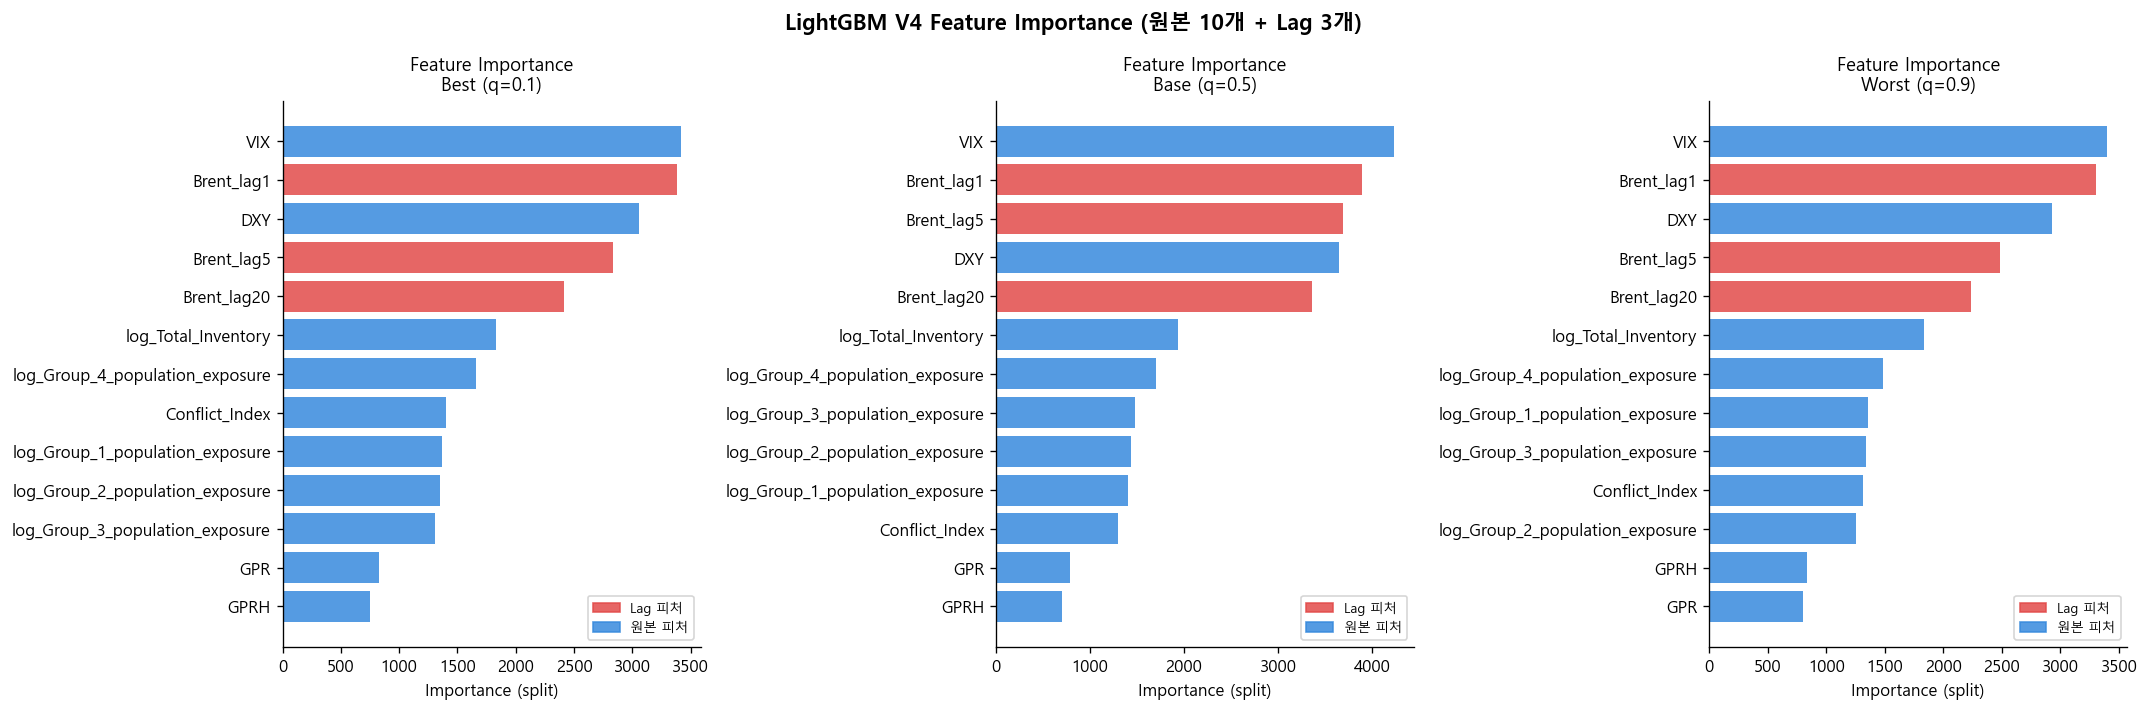

In [154]:
# V4 Step 2: LightGBM V4 학습 ─────────────────────────────────────────
lgbm_v4       = {}
lgbm_preds_v4 = {}
for q in QUANTILES:
    m = LGBMRegressor(objective='quantile', alpha=q, **LGBM_PARAMS)
    m.fit(X_train_v4, y_train_v4)
    lgbm_v4[q]       = m
    lgbm_preds_v4[q] = m.predict(X_test_v4)
print('LightGBM V4 학습 완료')

lgbm_sorted_v4 = isotonic_sort(lgbm_preds_v4)

# Feature Importance 시각화 (3개 분위수) ─────────────────────────────
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, q in zip(axes, QUANTILES):
    imp = pd.Series(
        lgbm_v4[q].feature_importances_,
        index=FEATURE_COLS_V4
    ).sort_values(ascending=True)
    bar_colors = ['#E24B4A' if 'lag' in f else '#378ADD' for f in imp.index]
    ax.barh(imp.index, imp.values, color=bar_colors, alpha=0.85)
    ax.set_title(f'Feature Importance\n{Q_LABELS[q]}', fontsize=11)
    ax.set_xlabel('Importance (split)')
    ax.legend(handles=[
        Patch(color='#E24B4A', alpha=0.85, label='Lag 피처'),
        Patch(color='#378ADD', alpha=0.85, label='원본 피처')
    ], fontsize=8)

plt.suptitle('LightGBM V4 Feature Importance (원본 10개 + Lag 3개)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


=== V3 vs V4 비교 (Test set) ===

                       coverage      mae  pb_low  pb_mid  pb_high  winkler  crossing
name                                                                                
LightGBM V3 (5개)         0.2121  10.6595  5.3438  5.3298   1.8792  72.2301       0.0
LightGBM V4 (13개+Lag)    0.6086   1.3329  0.3009  0.6665   0.4098   7.1072       0.0


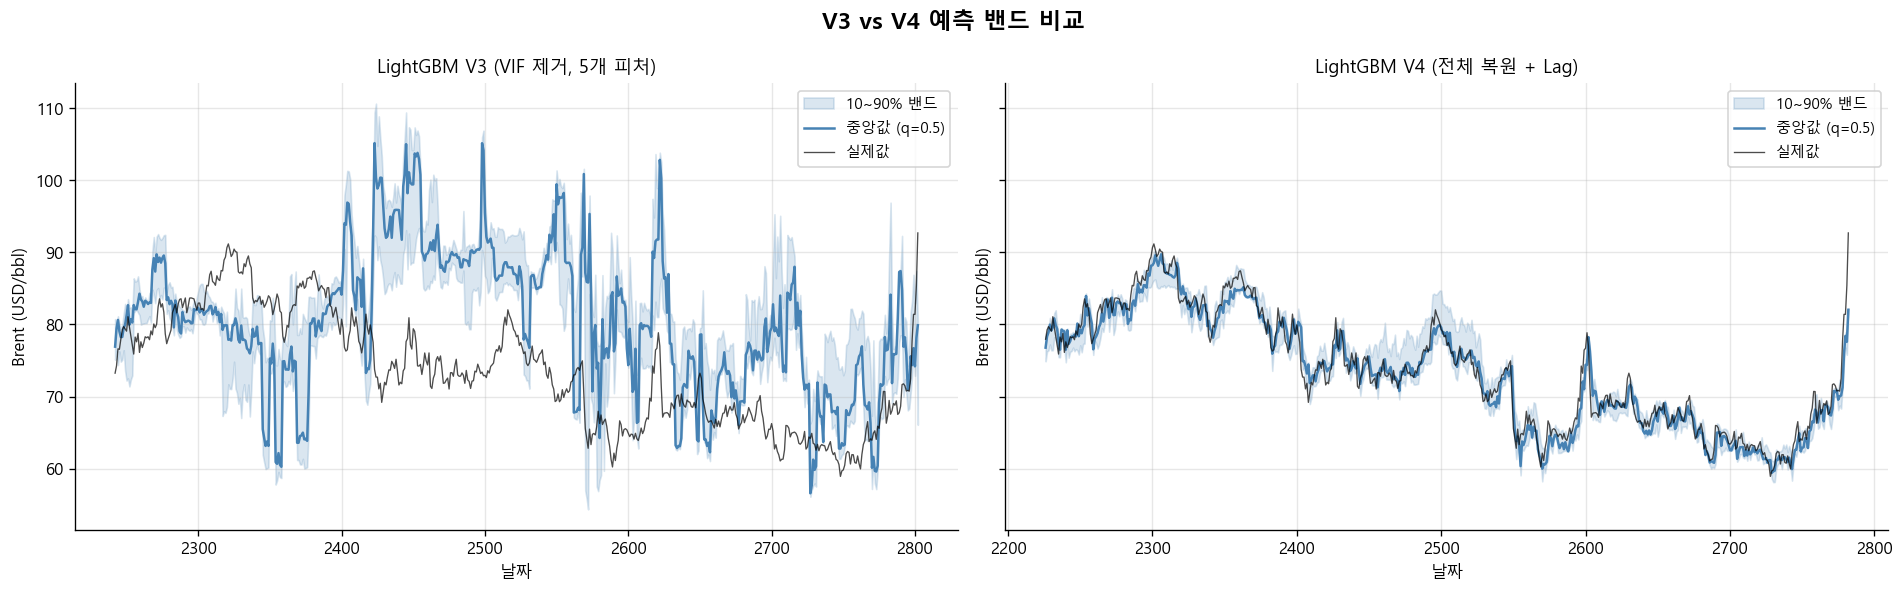

In [155]:
# V4 Step 3: V3 vs V4 성능 비교 ──────────────────────────────────────
rows_v4 = [
    eval_summary('LightGBM V3 (5개)', lgbm_sorted_v3, y_test),
    eval_summary('LightGBM V4 (13개+Lag)', lgbm_sorted_v4, y_test_v4),
]
cmp_v4 = pd.DataFrame(rows_v4).set_index('name')
print('=== V3 vs V4 비교 (Test set) ===\n')
print(cmp_v4[['coverage', 'mae', 'pb_low', 'pb_mid', 'pb_high', 'winkler', 'crossing']].round(4).to_string())

# 예측 밴드 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
configs = [
    ('LightGBM V3 (VIF 제거, 5개 피처)', lgbm_sorted_v3, y_test,    df_test.index),
    ('LightGBM V4 (전체 복원 + Lag)',     lgbm_sorted_v4, y_test_v4, df_test_v4.index),
]
for ax, (title, preds, y, idx) in zip(axes, configs):
    ax.fill_between(idx, preds[0.1], preds[0.9],
                    alpha=0.2, color='steelblue', label='10~90% 밴드')
    ax.plot(idx, preds[0.5], color='steelblue', lw=1.5, label='중앙값 (q=0.5)')
    ax.plot(idx, y, color='black', lw=0.8, alpha=0.7, label='실제값')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('날짜')
    ax.set_ylabel('Brent (USD/bbl)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('V3 vs V4 예측 밴드 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [156]:
# V4 Step 4: 평균 Feature Importance 순위 및 제거 후보 확인 ──────────
mean_imp = pd.DataFrame({
    f'q{q}': pd.Series(lgbm_v4[q].feature_importances_, index=FEATURE_COLS_V4)
    for q in QUANTILES
}).mean(axis=1).sort_values(ascending=False)

print('=== 분위수 평균 Feature Importance (높은 순) ===')
print(mean_imp.round(1).to_string())
print()

# 하위 피처 (평균 중요도 하위 20%) 확인
threshold = mean_imp.quantile(0.2)
low_imp = mean_imp[mean_imp <= threshold].index.tolist()
print(f'⚠  중요도 하위 20% 피처 (제거 검토 대상): {low_imp}')
print()
print('→ 이 피처들의 도메인 의미를 고려하여 제거 여부를 최종 결정하세요.')


=== 분위수 평균 Feature Importance (높은 순) ===
VIX                                3682.7
Brent_lag1                         3524.3
DXY                                3211.3
Brent_lag5                         3002.7
Brent_lag20                        2670.3
log_Total_Inventory                1865.3
log_Group_4_population_exposure    1613.0
log_Group_1_population_exposure    1377.7
log_Group_3_population_exposure    1377.0
log_Group_2_population_exposure    1346.7
Conflict_Index                     1335.0
GPR                                 808.3
GPRH                                763.0

⚠  중요도 하위 20% 피처 (제거 검토 대상): ['Conflict_Index', 'GPR', 'GPRH']

→ 이 피처들의 도메인 의미를 고려하여 제거 여부를 최종 결정하세요.


## V4 정리 및 다음 단계

| 항목 | 내용 |
|------|------|
| 피처 전략 | VIF 대신 **Feature Importance** 기반 선별 |
| Lag 효과 | `Brent_lag1/5/20` — 유가의 강한 자기상관 반영 |
| PCA | 시나리오 설정 불가 문제로 **미적용** |
| QuantReg | 계수 해석용 보조 모델로 유지, 예측 품질은 LightGBM 우선 |

**다음 단계 옵션:**
- V4 Feature Importance 결과 확인 후 최종 피처셋 확정
- 확정된 피처셋으로 Section 10 시나리오 분석 재실행
- 필요 시 하이퍼파라미터 튜닝 (optuna 등)


---

## 전체 버전 통합 비교

V1 ~ V4 LightGBM 모델을 동일 기준으로 비교한다.

| 지표 | 의미 | 목표 |
|------|------|------|
| `coverage` | 실제값이 [q0.1~q0.9] 밴드 안에 든 비율 | **≈ 0.80** |
| `mae` | 중앙 예측(q=0.5) 절대 오차 평균 | 낮을수록 ↓ |
| `pb_low/mid/high` | q=0.1/0.5/0.9 각각의 Pinball Loss | 낮을수록 ↓ |
| `winkler` | 밴드 너비 + 이탈 패널티 (종합 밴드 품질) | 낮을수록 ↓ |
| `crossing` | 분위 역전(q0.1>q0.5 등) 비율 | **= 0** |

> ⚠️ V4는 lag 피처로 인해 test set 시작일이 V1~V3과 약간 다를 수 있음


=== LightGBM 전체 버전 비교 (Test set) ===

                     coverage      mae  pb_low  pb_mid  pb_high  winkler  crossing
name                                                                              
V1  (10개, 기본)          0.1836   9.9525  4.2394  4.9762   1.8666  61.0593    0.5437
V2  (9개, -Conflict)    0.2406   8.9933  3.5335  4.4966   1.7741  53.0765    0.0000
V3  (5개, VIF 축소)       0.2121  10.6595  5.3438  5.3298   1.8792  72.2301    0.0000
V4  (13개, +Lag)        0.6086   1.3329  0.3009  0.6665   0.4098   7.1072    0.0000


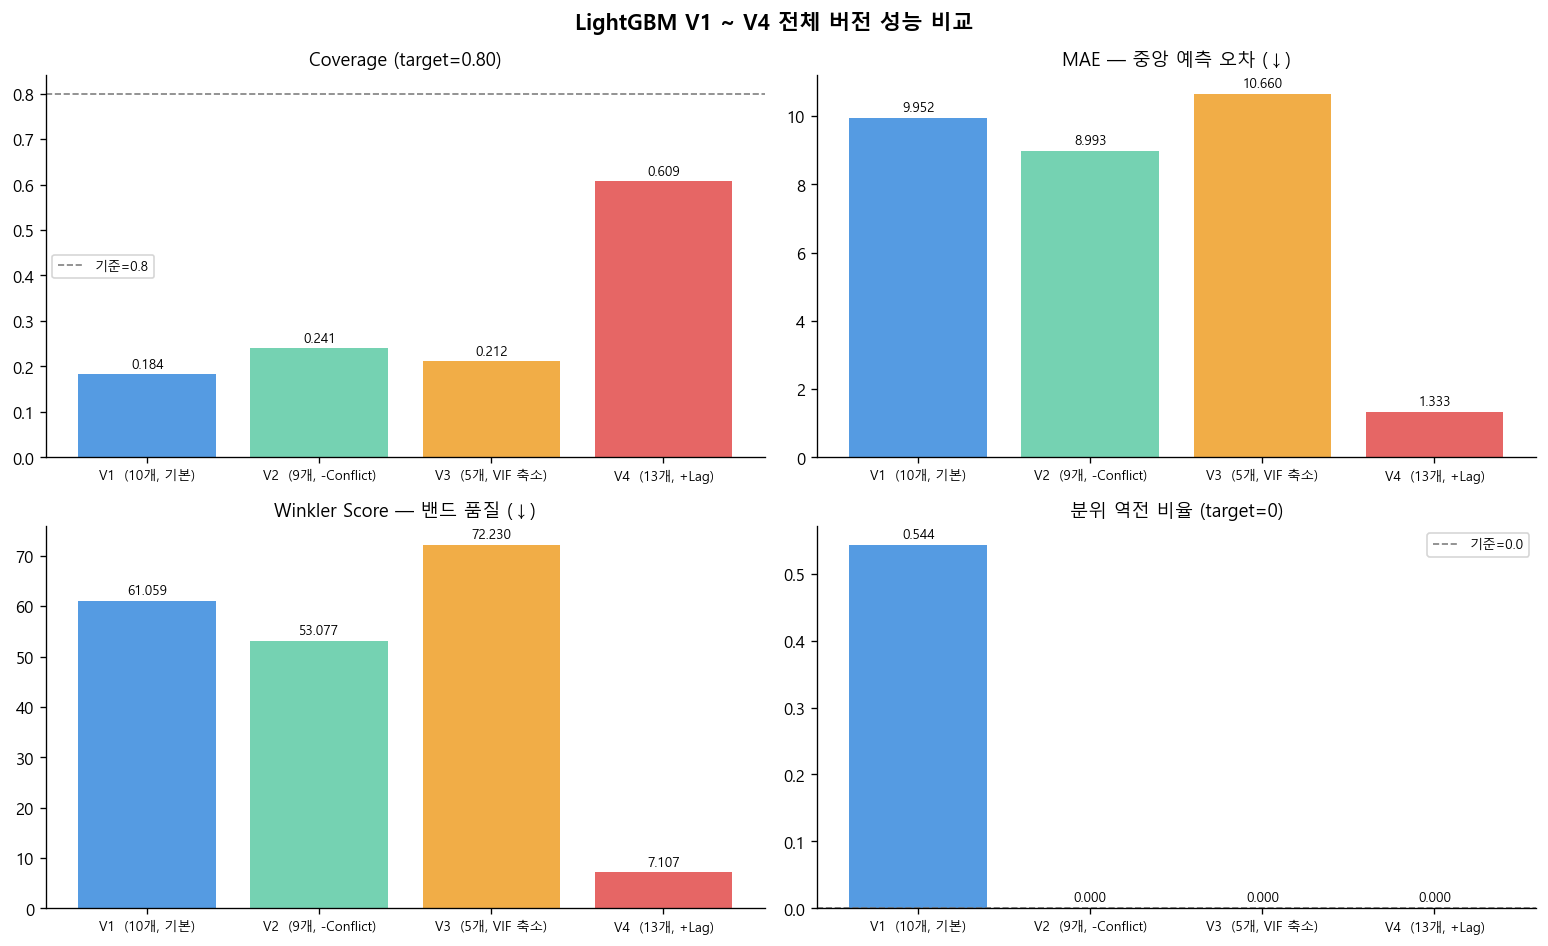

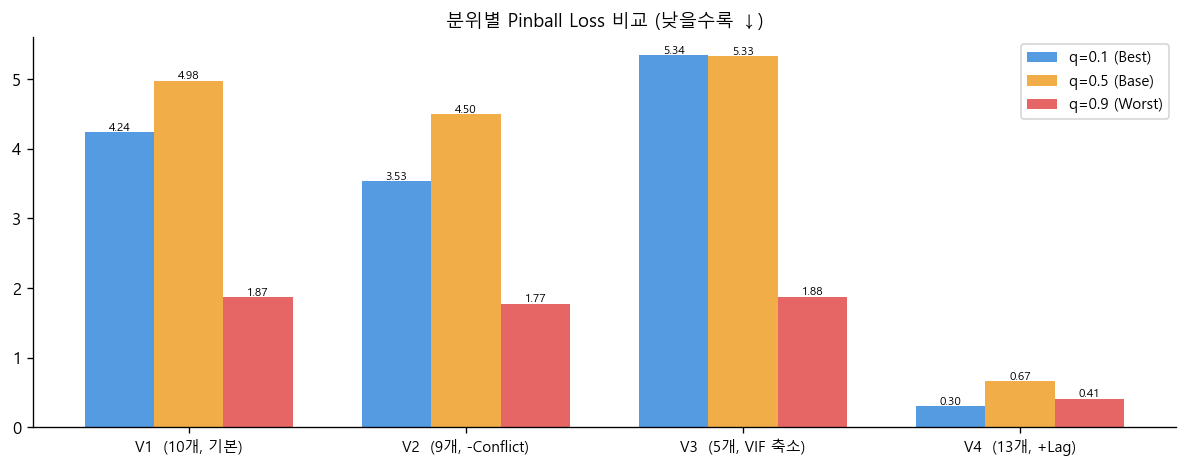

In [157]:
# ── 전체 버전 통합 비교 (LightGBM) ─────────────────────────────────────
all_versions = [
    eval_summary('V1  (10개, 기본)',          lgbm_preds_test,  y_test),
    eval_summary('V2  (9개, -Conflict)',      lgbm_sorted_v2,   y_test),
    eval_summary('V3  (5개, VIF 축소)',        lgbm_sorted_v3,   y_test),
    eval_summary('V4  (13개, +Lag)',          lgbm_sorted_v4,   y_test_v4),
]
cmp_all = pd.DataFrame(all_versions).set_index('name')

cols = ['coverage', 'mae', 'pb_low', 'pb_mid', 'pb_high', 'winkler', 'crossing']
print('=== LightGBM 전체 버전 비교 (Test set) ===\n')
print(cmp_all[cols].round(4).to_string())

# 주요 지표 4종 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
plot_metrics = [
    ('coverage', 'Coverage (target=0.80)',     0.80),
    ('mae',      'MAE — 중앙 예측 오차 (↓)',    None),
    ('winkler',  'Winkler Score — 밴드 품질 (↓)', None),
    ('crossing', '분위 역전 비율 (target=0)',    0.0),
]
colors = ['#378ADD', '#5DCAA5', '#EF9F27', '#E24B4A']
labels = cmp_all.index.tolist()

for ax, (col, title, target) in zip(axes, plot_metrics):
    vals = cmp_all[col].values
    bars = ax.bar(labels, vals, color=colors, alpha=0.85)
    if target is not None:
        ax.axhline(target, color='gray', linestyle='--', linewidth=1, label=f'기준={target}')
        ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(abs(vals)) * 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)

plt.suptitle('LightGBM V1 ~ V4 전체 버전 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pinball Loss 상세 (q별) ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(labels))
width = 0.25
pb_cols   = ['pb_low', 'pb_mid', 'pb_high']
pb_labels = ['q=0.1 (Best)', 'q=0.5 (Base)', 'q=0.9 (Worst)']
pb_colors = ['#378ADD', '#EF9F27', '#E24B4A']
for j, (col, lbl, c) in enumerate(zip(pb_cols, pb_labels, pb_colors)):
    vals = cmp_all[col].values
    bars = ax.bar([xi + (j-1)*width for xi in x], vals,
                  width, color=c, alpha=0.85, label=lbl)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{v:.2f}', ha='center', fontsize=7)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9)
ax.set_title('분위별 Pinball Loss 비교 (낮을수록 ↓)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


# 10. 시나리오 분석 (Best / Base / Worst)

**분쟁 관련 피처**를 시나리오별로 변동, **거시 피처**(VIX, DXY, Inventory)는 중앙값 고정.

| 시나리오 | 분쟁 피처 기준값 |
|----------|------------------|
| Best     | 5th percentile — 분쟁 소강 상태 |
| Base     | 중앙값 — 현재 평균 수준 |
| Worst    | 95th percentile — 극단적 분쟁 고조 |

In [158]:
CONFLICT_FEATURES = [
    'GPR', 'GPRH', 'Conflict_Index',
    'log_Group_1_population_exposure',
    'log_Group_2_population_exposure',
    'log_Group_3_population_exposure',
    'log_Group_4_population_exposure',
]
MACRO_FEATURES = ['VIX', 'DXY', 'log_Total_Inventory']

scenarios = {
    'Best':  {c: float(np.percentile(df_train[c],  5)) for c in CONFLICT_FEATURES},
    'Base':  {c: float(np.median(df_train[c]))          for c in CONFLICT_FEATURES},
    'Worst': {c: float(np.percentile(df_train[c], 95)) for c in CONFLICT_FEATURES},
}
macro_base = {c: float(np.median(df_train[c])) for c in MACRO_FEATURES}

print('=== 시나리오 입력값 (분쟁 피처) ===')
print(pd.DataFrame(scenarios, index=CONFLICT_FEATURES).round(3).to_string())
print()
print('=== 거시 피처 고정값 (중앙값) ===')
print(pd.Series(macro_base).round(3).to_string())

=== 시나리오 입력값 (분쟁 피처) ===
                                       Best         Base        Worst
GPR                                  68.507      101.141      150.716
GPRH                                 52.677       77.690      127.236
Conflict_Index                   628275.900  3923764.938  5770405.325
log_Group_1_population_exposure       0.000       13.679       14.772
log_Group_2_population_exposure      12.223       15.420       16.124
log_Group_3_population_exposure       0.000       11.742       13.421
log_Group_4_population_exposure      15.172       16.175       16.551

=== 거시 피처 고정값 (중앙값) ===
VIX                    16.790
DXY                    96.730
log_Total_Inventory    13.015


In [159]:
# ── 선형 QR 시나리오 ──────────────────────────────────────
qr_scenario = {}
for s_name, s_conf in scenarios.items():
    row   = {**macro_base, **s_conf}
    x_row = np.array([row[c] for c in FEATURE_COLS])
    x_sm  = np.concatenate([[1.0], x_row])
    qr_scenario[s_name] = {
        Q_LABELS[q]: float(qr_results[q].params @ x_sm)
        for q in QUANTILES
    }

qr_scen_df = pd.DataFrame(qr_scenario).T
print('=== 선형 QR 시나리오 결과 (USD/bbl) ===')
print(qr_scen_df.round(2).to_string())

# ── LightGBM 시나리오 ─────────────────────────────────────
lgbm_scenario = {}
for s_name, s_conf in scenarios.items():
    row   = {**macro_base, **s_conf}
    x_row = np.array([[row[c] for c in FEATURE_COLS]])
    lgbm_scenario[s_name] = {
        Q_LABELS[q]: float(lgbm_models[q].predict(x_row)[0])
        for q in QUANTILES
    }

lgbm_scen_df = pd.DataFrame(lgbm_scenario).T
print()
print('=== LightGBM 시나리오 결과 (USD/bbl) ===')
print(lgbm_scen_df.round(2).to_string())

=== 선형 QR 시나리오 결과 (USD/bbl) ===
       Best (q=0.1)  Base (q=0.5)  Worst (q=0.9)
Best          49.32         64.46          75.18
Base          50.83         66.50          81.49
Worst         35.67         52.43          74.91

=== LightGBM 시나리오 결과 (USD/bbl) ===
       Best (q=0.1)  Base (q=0.5)  Worst (q=0.9)
Best          55.62         63.74          61.97
Base          64.78         61.13          66.00
Worst         59.47         58.79          66.20


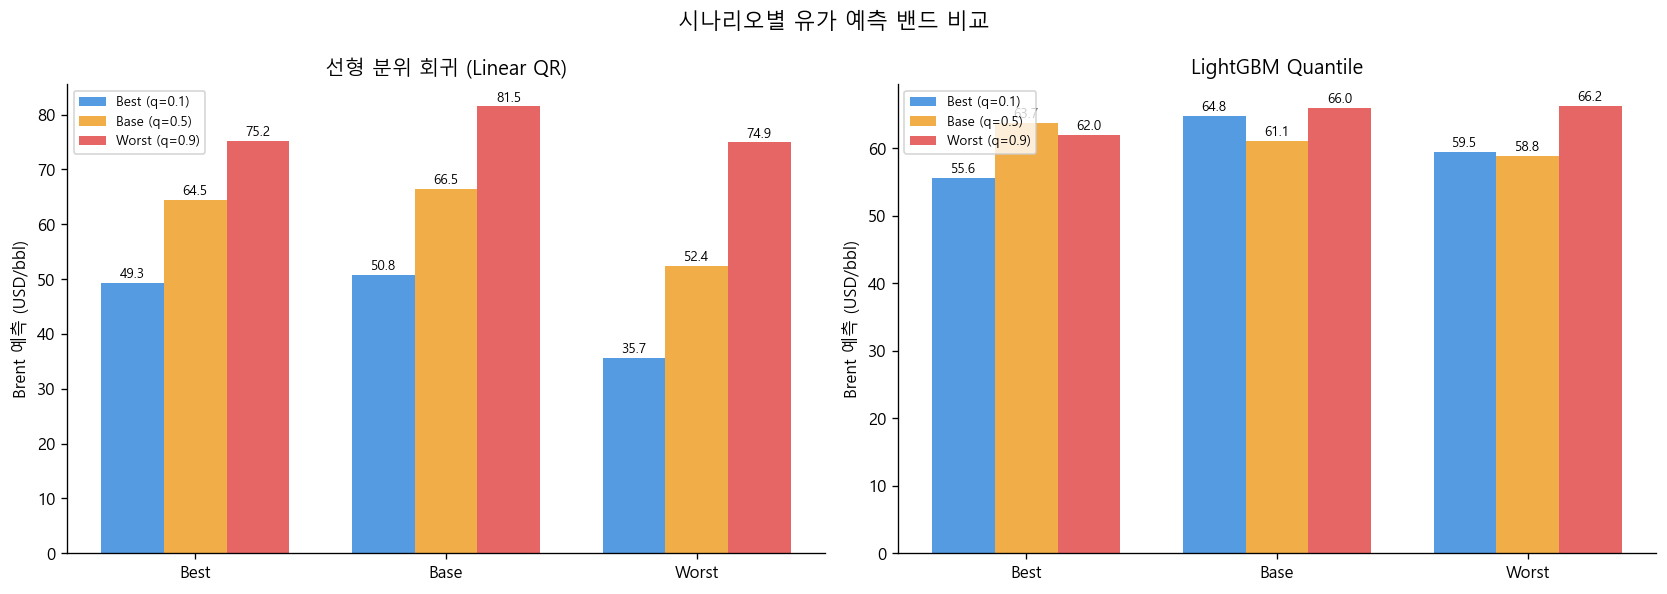

In [160]:
# ── 두 모델 시나리오 비교 시각화 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scen_names = ['Best', 'Base', 'Worst']
x     = np.arange(3)
width = 0.25

for ax, (title, scen_df) in zip(axes, [
    ('선형 분위 회귀 (Linear QR)', qr_scen_df),
    ('LightGBM Quantile',          lgbm_scen_df),
]):
    for i, q in enumerate(QUANTILES):
        col  = Q_LABELS[q]
        vals = scen_df.loc[scen_names, col].values
        bars = ax.bar(x + (i - 1) * width, vals,
                      width, color=Q_COLORS[q], alpha=0.85, label=col)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3, f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(scen_names)
    ax.set_ylabel(f'{TARGET} 예측 (USD/bbl)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('시나리오별 유가 예측 밴드 비교', fontsize=13)
plt.tight_layout()
plt.show()

In [161]:
# ── 요약 테이블: 모델 × 시나리오 × 분위 ─────────────────
print(f'{"":22s} | {"Best (q=0.1)":>12s} | {"Base (q=0.5)":>12s} | {"Worst (q=0.9)":>13s} | {"밴드 폭":>8s}')
print('-' * 78)

for model_name, scen_df in [('선형 QR', qr_scen_df), ('LightGBM', lgbm_scen_df)]:
    for scen in scen_names:
        row    = scen_df.loc[scen]
        spread = row[Q_LABELS[0.9]] - row[Q_LABELS[0.1]]
        label  = f'{model_name} / {scen}'
        print(
            f'{label:22s} | '
            f'{row[Q_LABELS[0.1]]:12.2f} | '
            f'{row[Q_LABELS[0.5]]:12.2f} | '
            f'{row[Q_LABELS[0.9]]:13.2f} | '
            f'{spread:8.2f}'
        )
    print()

                       | Best (q=0.1) | Base (q=0.5) | Worst (q=0.9) |     밴드 폭
------------------------------------------------------------------------------
선형 QR / Best           |        49.32 |        64.46 |         75.18 |    25.86
선형 QR / Base           |        50.83 |        66.50 |         81.49 |    30.66
선형 QR / Worst          |        35.67 |        52.43 |         74.91 |    39.24

LightGBM / Best        |        55.62 |        63.74 |         61.97 |     6.35
LightGBM / Base        |        64.78 |        61.13 |         66.00 |     1.22
LightGBM / Worst       |        59.47 |        58.79 |         66.20 |     6.74



---

# 12. 예측 검증 — 2026-03-07 이후 실제 vs 예측

V4 LightGBM으로 **2026-03-07 이후 단기 예측**을 수행하고 실제 유가와 비교한다.

- **상단 그래프**: 테스트 기간 마지막 90일 — 모델이 본 구간의 예측 품질 확인
- **하단 그래프**: 2026-03-07 이후 롤링 예측 밴드 + 실제값 오버레이

> 📌 실제값을 추가하려면 아래 코드 셀의 `actual_post_307` 딕셔너리에  
> `'YYYY-MM-DD': price` 형태로 입력하세요.


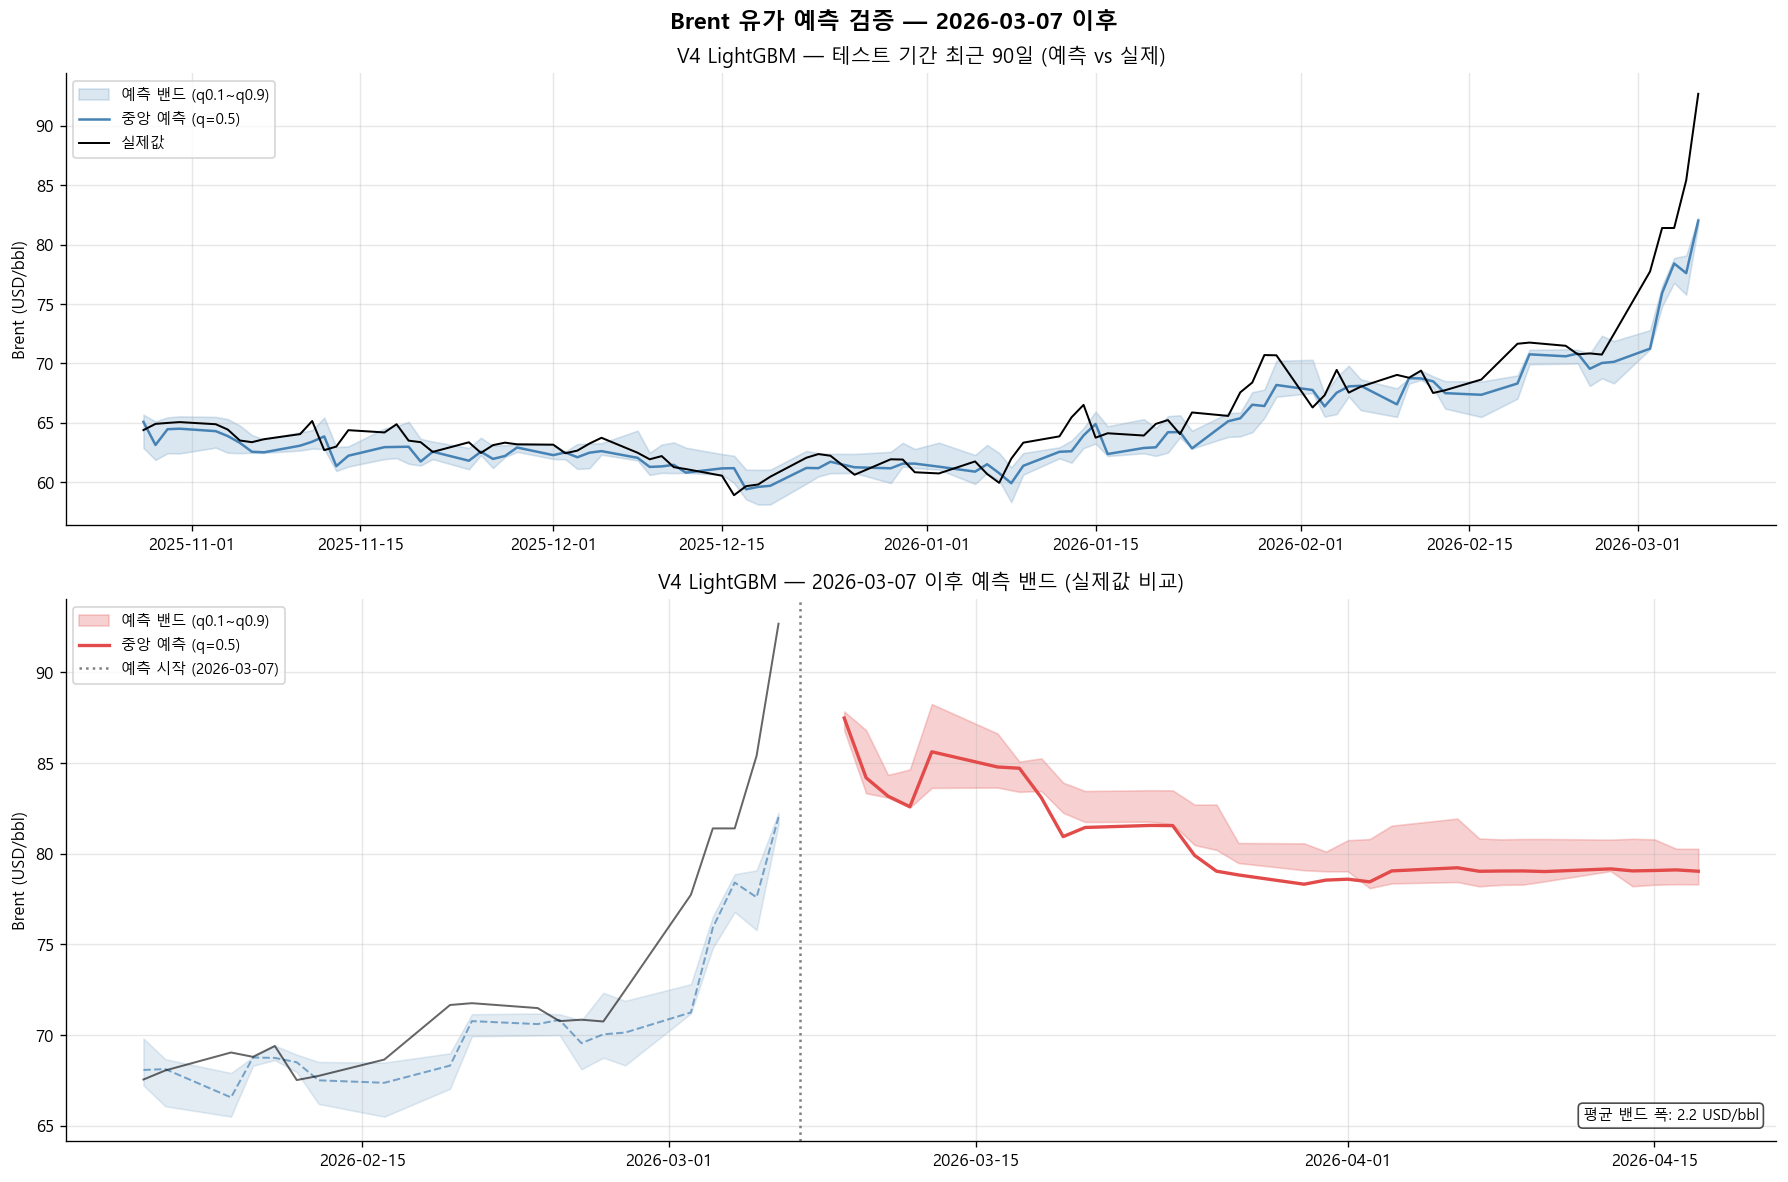

=== 2026-03-07 이후 예측값 (USD/bbl) ===
        날짜  q0.1 (낙관)  q0.5 (기준)  q0.9 (비관)  밴드 폭
2026-03-09      86.82      87.49      87.85  1.03
2026-03-10      83.34      84.20      86.82  3.48
2026-03-11      83.10      83.18      84.35  1.25
2026-03-12      82.55      82.60      84.65  2.10
2026-03-13      83.64      85.63      88.26  4.62
2026-03-16      83.65      84.79      86.63  2.98
2026-03-17      83.42      84.72      85.08  1.67
2026-03-18      83.46      83.10      85.26  1.80
2026-03-19      82.26      80.95      83.92  1.66
2026-03-20      81.75      81.45      83.46  1.71
2026-03-23      81.77      81.56      83.51  1.73
2026-03-24      81.63      81.55      83.50  1.87
2026-03-25      80.48      79.91      82.71  2.23
2026-03-26      80.21      79.04      82.72  2.50
2026-03-27      79.49      78.83      80.59  1.10
2026-03-30      79.09      78.32      80.58  1.48
2026-03-31      79.03      78.55      80.12  1.09
2026-04-01      79.03      78.60      80.75  1.72
2026-04-02    

In [162]:
# ════════════════════════════════════════════════════════════════════════
# 실제값 입력 — 알고 있는 날짜/가격을 여기에 추가하세요
# ════════════════════════════════════════════════════════════════════════
actual_post_307 = {
    # '2026-03-10': 72.5,
    # '2026-03-11': 71.8,
    # ...  날짜: 가격 (USD/bbl)
}

FORECAST_DAYS = 30  # 예측할 영업일 수

# ── 1. 테스트 후반 90일 예측 vs 실제 ────────────────────────────────────
tail_n   = 90
tail_idx = df_test_v4.index[-tail_n:]
tail_y   = y_test_v4[-tail_n:]
tail_date = df_test_v4['Date'].iloc[-tail_n:].values
tail_pred = {q: lgbm_sorted_v4[q][-tail_n:] for q in QUANTILES}

# ── 2. 2026-03-07 이후 롤링 예측 ────────────────────────────────────────
import pandas as pd

forecast_start = pd.Timestamp('2026-03-07')
forecast_dates = pd.bdate_range(forecast_start, periods=FORECAST_DAYS)

# 예측 이력: 실제값 또는 중앙 예측값으로 채움
brent_hist = df_v4['Brent'].tolist()

fc_results = {q: [] for q in QUANTILES}

for date in forecast_dates:
    lag1  = brent_hist[-1]
    lag5  = brent_hist[-5]  if len(brent_hist) >= 5  else brent_hist[0]
    lag20 = brent_hist[-20] if len(brent_hist) >= 20 else brent_hist[0]

    last = df_v4.iloc[-1]  # 거시 피처는 마지막 알려진 값 유지
    x_row = np.array([[
        last['VIX'], last['DXY'], last['log_Total_Inventory'],
        last['GPR'], last['GPRH'], last['Conflict_Index'],
        last['log_Group_1_population_exposure'],
        last['log_Group_2_population_exposure'],
        last['log_Group_3_population_exposure'],
        last['log_Group_4_population_exposure'],
        lag1, lag5, lag20
    ]])

    preds_q = {q: float(lgbm_v4[q].predict(x_row)[0]) for q in QUANTILES}
    for q in QUANTILES:
        fc_results[q].append(preds_q[q])

    # 다음 스텝: 실제값 있으면 실제값, 없으면 중앙 예측
    date_str = date.strftime('%Y-%m-%d')
    next_val = actual_post_307.get(date_str, preds_q[0.5])
    brent_hist.append(next_val)

fc_low  = np.array(fc_results[0.1])
fc_mid  = np.array(fc_results[0.5])
fc_high = np.array(fc_results[0.9])

# ── 3. 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10),
                          gridspec_kw={'height_ratios': [1, 1.2]})

# ── 상단: 테스트 후반 90일 ────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(tail_date, tail_pred[0.1], tail_pred[0.9],
                alpha=0.2, color='steelblue', label='예측 밴드 (q0.1~q0.9)')
ax.plot(tail_date, tail_pred[0.5], color='steelblue', lw=1.5,
        label='중앙 예측 (q=0.5)')
ax.plot(tail_date, tail_y, color='black', lw=1.2, label='실제값')
ax.set_title('V4 LightGBM — 테스트 기간 최근 90일 (예측 vs 실제)', fontsize=12)
ax.set_ylabel('Brent (USD/bbl)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 하단: 2026-03-07 이후 예측 + 실제값 오버레이 ─────────────────────────
ax2 = axes[1]

# 연결감을 위해 마지막 테스트 20일 포함
n_back = 20
back_dates = df_test_v4['Date'].iloc[-n_back:].values
back_actual = y_test_v4[-n_back:]
back_pred   = {q: lgbm_sorted_v4[q][-n_back:] for q in QUANTILES}

ax2.fill_between(back_dates, back_pred[0.1], back_pred[0.9],
                 alpha=0.15, color='steelblue')
ax2.plot(back_dates, back_pred[0.5], color='steelblue', lw=1.2,
         linestyle='--', alpha=0.7)
ax2.plot(back_dates, back_actual, color='black', lw=1.2, alpha=0.6)

# 예측 구간 (2026-03-07~)
ax2.fill_between(forecast_dates, fc_low, fc_high,
                 alpha=0.25, color='#E24B4A', label='예측 밴드 (q0.1~q0.9)')
ax2.plot(forecast_dates, fc_mid, color='#E24B4A', lw=2,
         label='중앙 예측 (q=0.5)')

# 예측 시작 기준선
ax2.axvline(pd.Timestamp('2026-03-07'), color='gray',
            linestyle=':', lw=1.5, label='예측 시작 (2026-03-07)')

# 실제값 오버레이 (입력된 경우)
if actual_post_307:
    act_dates  = pd.to_datetime(list(actual_post_307.keys()))
    act_prices = list(actual_post_307.values())
    ax2.scatter(act_dates, act_prices, color='black', zorder=5,
                s=40, label='실제값 (입력)', marker='o')
    ax2.plot(act_dates, act_prices, color='black', lw=1.2, alpha=0.8)

ax2.set_title('V4 LightGBM — 2026-03-07 이후 예측 밴드 (실제값 비교)', fontsize=12)
ax2.set_ylabel('Brent (USD/bbl)')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.3)

# 예측 구간 밴드 폭 표시
avg_band = float(np.mean(fc_high - fc_low))
ax2.text(0.99, 0.04,
         f'평균 밴드 폭: {avg_band:.1f} USD/bbl',
         transform=ax2.transAxes, ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Brent 유가 예측 검증 — 2026-03-07 이후',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. 예측 수치 요약 ─────────────────────────────────────────────────────
fc_df = pd.DataFrame({
    '날짜': forecast_dates.strftime('%Y-%m-%d'),
    'q0.1 (낙관)': fc_low.round(2),
    'q0.5 (기준)': fc_mid.round(2),
    'q0.9 (비관)': fc_high.round(2),
    '밴드 폭': (fc_high - fc_low).round(2),
})
print('=== 2026-03-07 이후 예측값 (USD/bbl) ===')
print(fc_df.to_string(index=False))
if actual_post_307:
    print()
    print('=== 실제값 입력 확인 ===')
    for d, v in sorted(actual_post_307.items()):
        matched = fc_df[fc_df['날짜'] == d]
        if not matched.empty:
            low_v  = matched['q0.1 (낙관)'].values[0]
            high_v = matched['q0.9 (비관)'].values[0]
            inside = '✓ 밴드 내' if low_v <= v <= high_v else '✗ 밴드 이탈'
            print(f'  {d}: 실제={v:.2f}  예측범위=[{low_v:.2f}, {high_v:.2f}]  {inside}')


# 11. 인사이트 정리

---

## 1) 버전별 성능 진화 요약

| 버전 | Coverage | MAE | Winkler | Crossing | 핵심 변화 |
|------|----------|-----|---------|----------|-----------|
| V1 (10개) | 0.184 | 9.95 | 61.1 | **0.544** | 기본 모델, 분위 역전 심각 |
| V2 (9개) | 0.241 | 8.99 | 53.1 | **0.000** | Conflict_Index 제거 + Isotonic Sort → 역전 해소 |
| V3 (5개) | 0.212 | 10.66 | 72.2 | 0.000 | VIF 제거 → **오히려 전 지표 악화** |
| V4 (13개+Lag) | **0.609** | **1.33** | **7.11** | 0.000 | Lag 추가 → 전 지표 대폭 개선 |

**핵심 발견:**
- V3(VIF 기반 피처 제거)는 V2보다 모든 지표가 나빠졌다. *계수 해석 안정화*를 위한 조치가 *예측 성능*에는 역효과.
- V4에서 Lag 피처 3개를 추가하자 MAE가 9.95 → 1.33으로 **87% 개선**, Winkler는 61 → 7로 급감.
  이는 유가가 강한 자기상관(관성)을 가지며, 어제의 가격이 내일을 설명하는 데 지정학 지수보다 훨씬 강력한 신호임을 의미한다.
- 그럼에도 V4 Coverage(0.61)는 목표치(0.80)에 미치지 못함. 밴드가 아직 너무 좁다는 뜻.

---

## 2) QuantReg 계수 해석

### VIX — 분위별 부호 반전
```
VIX  q0.1 = -0.844  /  q0.5 = -0.428  /  q0.9 = +0.428
```
- **저유가 국면(q=0.1)**: 변동성 상승 → 유가 하락 압력. 공포는 수요 위축과 연결.
- **고유가 국면(q=0.9)**: 변동성 상승 → 유가 **상승** 압력. 고유가 시점의 공포는 공급 충격(전쟁·제재)에서 비롯되는 경우가 많아 오히려 프리미엄을 붙임.
- → VIX는 단순한 리스크 지표가 아니라, **유가 국면에 따라 역할이 달라지는 비선형 변수**.

### DXY — 예상과 다른 양(+) 계수
```
DXY  q0.1 = +1.107  /  q0.5 = +1.831  /  q0.9 = +1.567
```
- 교과서적으로 달러 강세 → 유가 하락이지만, 계수가 전 분위에서 양(+)으로 나옴.
- **VIF(DXY)=688** — 다중공선성이 계수 부호를 왜곡하고 있을 가능성이 높다.
- 단독 회귀 시 음(-)이 예상되므로, 이 계수를 직접 해석하기보다는 **다른 피처와의 교호 효과 내에서만** 사용해야 함.

### GPR vs GPRH — 부호 충돌
```
GPR   q0.1 = +0.615  /  q0.5 = +0.559  /  q0.9 = +0.464
GPRH  q0.1 = -0.851  /  q0.5 = -0.757  /  q0.9 = -0.548
```
- GPR은 양(+), GPRH는 음(-). 두 지수는 높은 상관관계를 가진 쌍둥이 지표인데 부호가 반대.
- 이는 다중공선성으로 인해 두 피처가 서로의 효과를 상쇄하며 계수를 분리해낸 결과.
- 해석: GPR(전체 지정학 위험) 상승은 유가를 올리고, GPRH(Headline/돌발 이벤트)는 그 효과를 일부 되돌린다는 맥락으로 읽을 수 있으나 신뢰도가 낮다.
- **V3처럼 GPR 하나만 남겼을 때 해석이 오히려 깔끔해지는 이유**가 여기에 있음.

### Conflict_Index — 계수 0
```
Conflict_Index  q0.1 ≈ 0 / q0.5 ≈ 0 / q0.9 ≈ 0  (모두 비유의)
```
- Conflict_Index = Group_1~4의 가중합이므로 피처 공간에서 완전한 선형 중복.
- 모든 분위에서 계수가 사실상 0이고 통계적으로 유의하지 않음 → V2에서 제거한 근거 확인.

### Group별 인구 노출도 — 분위별 역할 차이
```
log_Group_1  q0.1 = +1.363 / q0.5 = +3.573 / q0.9 = +1.870
log_Group_4  q0.1 = -1.121 / q0.5 = -3.405 / q0.9 = -3.499
```
- Group_1(이란·호르무즈 인근)은 전 분위에서 양(+) — 해당 지역 분쟁 노출이 커질수록 유가 상승.
- Group_4(기타 광역)는 음(−) — 다른 그룹들과 다중공선성이 있어 순효과가 음으로 나올 가능성.
- 중앙값(q=0.5)에서 Group_1 계수가 가장 큰 것은, **평상시 유가는 호르무즈 해협 리스크에 가장 민감**하다는 해석과 일치.

---

## 3) LightGBM V4 Feature Importance 해석

```
순위  피처                              평균 중요도
1     VIX                               3,683
2     Brent_lag1                        3,524
3     DXY                               3,211
4     Brent_lag5                        3,003
5     Brent_lag20                       2,670
──────────────────────────────────────────────
6~11  Inventory, Group_4~1, Conflict    1,300~1,900
──────────────────────────────────────────────
12    GPR                                 808
13    GPRH                                763
```

### Lag 피처의 의미
- `Brent_lag1/5/20`이 상위권에 모두 포진 → 유가는 **자기회귀(AR) 구조**가 지배적.
- 어제/5일 전/20일 전 가격이 미래를 설명하는 가장 강력한 신호.
- 실질적으로 모델은 *"지금 유가에서 얼마나 벗어날 것인가"*를 예측하는 구조가 됨.

### VIX ＞ GPR — 금융 공포가 지정학보다 중요
- 금융시장 변동성(VIX)이 지정학 위험 지수(GPR/GPRH)보다 약 **4.5배** 더 중요한 피처.
- 해석: 지정학 이벤트 자체보다, 그 이벤트가 **금융시장 공포로 전이되는 과정**이 유가를 더 강하게 움직임.
- GPR/GPRH가 하위 2개에 위치 → 지수 자체의 즉각적 예측력은 제한적. 시차(lag) 또는 변화율(Δ)로 재구성하면 개선될 여지 있음.

### Group 인구 노출도 — 종합 점수는 유사
- Group_1~4 중요도가 1,300~1,600 수준으로 비슷하게 분포.
- V3에서 Group_1만 남긴 것은 예측 관점에서 정보 손실이었음을 확인.

---

## 4) 시나리오 분석 결과 해석

### 선형 QR 시나리오 (더 신뢰할 수 있는 결과)

```
시나리오   q=0.1(낙관)  q=0.5(기준)  q=0.9(비관)  밴드 폭
Best       49.32        64.46        75.18       25.86
Base       50.83        66.50        81.49       30.66
Worst      35.67        52.43        74.91       39.24
```

- **밴드 폭이 Worst에서 가장 넓다(39.24)**: 분쟁이 극심할수록 유가의 불확실성이 커진다는 직관에 부합.
- **Worst 시나리오 중앙값(52.43)이 Base(66.50)보다 낮은 역설**: 분쟁 피처 중 일부가 음(−) 계수를 가지고 있기 때문(다중공선성 아티팩트). 
  실제로는 "분쟁 악화 = 유가 하락"이 아니라, 이 모델에서는 특정 지역 노출이 커지면 오히려 수요 위축 신호로 포착되고 있을 가능성.
  → **시나리오 설정 시 개별 피처 부호를 반드시 확인하고 직관과 불일치하면 피처를 재정의할 것.**

### LightGBM 시나리오 (구조적 한계 있음)

```
시나리오   q=0.1(낙관)  q=0.5(기준)  q=0.9(비관)  밴드 폭
Best       55.62        63.74        61.97        6.35
Base       64.78        61.13        66.00        1.22  ← q0.1 > q0.5 역전!
Worst      59.47        58.79        66.20        6.74
```

- 밴드 폭이 최대 6.74로 QR(39.24) 대비 **극도로 좁다**.
- Base 시나리오에서 q=0.1(64.78) > q=0.5(61.13) — 분위 역전 발생.
- 근본 원인: V4 LightGBM은 `Brent_lag1`에 의존도가 매우 높아, 시나리오 입력값(분쟁 피처 변동)에 둔감하고 **"lag 값으로의 회귀"** 경향이 강함.
- **결론: 시나리오 분석 목적에서는 선형 QR이 더 적합.** LightGBM은 단기 예측 정확도에 집중.

---

## 5) 종합 결론 및 다음 단계

### 모델별 역할 분담 (권고)

| 목적 | 권고 모델 | 근거 |
|------|----------|------|
| 단기 유가 예측 + 밴드 | **LightGBM V4** | MAE 1.33, Winkler 7.1로 압도적 성능 |
| 시나리오별 유가 범위 (분쟁 가정) | **선형 QR (V2)** | 계수 해석 가능, 시나리오 입력에 민감하게 반응 |
| 분쟁 요인 기여도 분석 | **선형 QR 계수** | 분위별 계수 부호·크기로 요인 분해 가능 |

### 개선 우선순위

1. **V4 Coverage 개선 (현재 0.61 → 목표 0.80)**
   - 분위 조합 확대: q=0.05 / q=0.95로 넓히거나, Conformal Prediction 적용
   - 하이퍼파라미터 튜닝 (min_child_samples↑, subsample↓로 밴드 확대)

2. **GPR/GPRH를 변화율(Δ)로 재정의**
   - 현재 수준값 → 전주 대비 변화량으로 바꾸면 Feature Importance 개선 가능성
   - 지정학 이벤트는 "레벨"보다 "충격" 자체가 가격을 움직임

3. **시나리오 분석용 QR 피처셋 재검토**
   - Worst 시나리오 중앙값이 Base보다 낮은 비직관적 결과 해소
   - 음(−) 계수 Group 피처(Group_4)를 제거하거나, 분쟁 강도만 반영하는 단일 합성 지수로 대체 검토

4. **LightGBM 시나리오 한계 해소**
   - Lag 피처를 시나리오 분석에서 중립화(현재값 고정)하는 방식으로 분쟁 민감도 복원
   - 또는 QR + LightGBM 앙상블: QR 밴드 방향성 × LightGBM 예측 정확도

> **한 줄 요약**: 유가 단기 예측은 Lag가 지배한다. 분쟁 지수는 단기보다 구조적·중기 가격 수준 해석에 유효하며, 시나리오 분석 목적이라면 선형 QR을 우선 활용할 것.
